**Normalizing Flows**

---



El VAE fue es un ejemplo de modelo generativo capaz de tomar muestras de $P(x)$. Un VAE también puede estimar $P(x)$ yendo del codificador a $z$, y luego utilizando la distribución conocida $P(z)$. Sin embargo, los VAE no suelen ser buenos en ninguna de estas tareas. Sus muestras se describen a menudo como "borrosas" porque tienen un comportamiento de búsqueda de la media. Es decir, las muestras individuales no corresponden a un ejemplo muy probable (no buscan el modo). En cambio, la distribución de las muestras es buena (búsqueda de la media). **Las redes generativas adversariales** (GAN) son una alternativa a las VAE que tienen muestras de alta probabilidad. Sin embargo, ambos métodos suelen tener problemas de entrenamiento y también dan malas estimaciones de $P(x)$ debido tanto a la falta de normalización como a los supuestos de distribuciones normales. Una alternativa es un **flujo de normalización** que tiene mejor estabilidad de entrenamiento y mejores estimaciones de $P(x)$. Los flujos normalizadores también se utilizan como componentes en otras redes, como puede actuar como $P(z)$ de un espacio latente para un VAE en lugar de distribuciones normales estándar.


Un **flujo de normalización** es similar a un VAE en el sentido de que intentamos construir $P(x)$ partiendo de una distribución simple conocida $P(z)$. Utilizamos funciones, como el descodificador de un VAE, para ir de $x$ a $z$. Sin embargo, nos aseguramos de que las funciones que elegimos mantienen la masa de probabilidad normalizada ($suma P(x) = 1$) y pueden utilizarse hacia delante (para muestrear desde x) y hacia atrás (para calcular $P(x)$). Llamamos a estas funciones **biyectores** porque son biyectivas (suyectivas e inyectivas). Recordemos que suyectiva significa que cada salida tiene una entrada correspondiente e inyectiva significa que cada salida tiene exactamente una entrada correspondiente.

Un ejemplo de biyector es un coseno elemento a elemento $y_i = \cos x_i$ (suponiendo que $x_i$ está entre $0$ y $\pi$). Una función no biyectiva sería $y_i = \cos x_i$ en el intervalo comprendido entre $0$ y $2\pi$, porque extrae todos los valores de $[0,1]$ dos veces y, por tanto, no es inyectiva. Cualquier función que cambie el número de elementos es automáticamente no biyectiva (ver nota al margen). Una consecuencia de utilizar sólo biyectores en la construcción de nuestro flujo normalizador es que el tamaño del espacio latente debe ser igual al tamaño del espacio de características. Recordemos que la VAE utiliza un espacio latente más pequeño que el espacio de rasgos.


**Flow Equation**


---
Recordemos que para el decodificador VAE, teníamos una fórmula explícita para $p(x | z)$. Esto nos permitió calcular $p(x) = \int\,dz p(x | z)p(z)$ que es la cantidad de interés. El decodificador VAE es una función de densidad de probabilidad condicional. En el flujo normalizador, no utilizamos funciones de densidad de probabilidad. Utilizamos funciones biyectivas. Así que no podemos simplemente calcular una integral para cambiar las variables. Podemos utilizar la fórmula de cambio de variable. Consideremos que nuestro flujo normalizador está definido por nuestro biyector $x = f(z)$, su inverso $z = g(x)$, y la distribución de probabilidad inicial $P_z(z)$. Entonces la fórmula de probabilidad de $x$ es

$$
P(x) = P_z\left(g(x)\right) \,\left| \textrm{det}\left[\mathbf{J}_g\right]\right|
$$

donde el término de la derecha es el valor absoluto del determinante del Jacobiano de $g$. [Jacobianos](https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant) son matrices que describen cómo los cambios infinitesimales en cada dimensión de dominio cambiar cada dimensión de rango. Este término corrige el cambio de volumen de la distribución. Por ejemplo, si $f(z) = 2z$, entonces $g(x) = x / 2$, y el determinante jacobiano es $1 / 2$. La intuición es que estamos estirando $z$ en 2, por lo que necesitamos tener en cuenta el aumento de volumen para mantener la probabilidad normalizada.

Puedes leer más sobre la fórmula de cambio de variable para [distribuciones de probabilidad aquí](https://cranmer.github.io/stats-ds-book/distributions/change-of-variables.html)

**Biyectores**

---
Un biyector es una función [inyectiva](https://en.wikipedia.org/wiki/Injective_function) (1 a 1) y [suryectiva](https://en.wikipedia.org/wiki/Surjective_function) (existe). Una forma equivalente de ver una función biyectiva es si tiene inversa. Por ejemplo, una reducción de la suma no tiene inversa y por lo tanto no es biyectiva. $\sum [1,0] = 1$ y $\sum [-1, 2] = 1$. La multiplicación por una matriz que tiene inversa es biyectiva. $y = x^2$ no es biyectiva, ya que $y = 4$ tiene dos soluciones.

<br>
Recordemos que debemos calcular el determinante del jacobiano del biyector. Si el Jacobiano es denso (todos los elementos de salida dependen de todos los elementos de entrada), calcular esta cantidad será $O\left(|x|_0^3\right)$ donde $|x|_0$ es el número de dimensiones de $x$ porque un determinante escala por $O(n^3)$. Esto haría que el cálculo de los flujos normalizadores fuera poco práctico en dimensiones altas. Sin embargo, en la práctica nos limitamos a biyectores que tienen Jacobianos fáciles de calcular. Por ejemplo, si el biyector es $x_i = \cos z_i$ entonces el Jacobiano será diagonal. Un jacobiano diagonal significa que cada dimensión es independiente de la otra.

<br>
Una forma de obtener determinantes más rápidos sin limitarse a independizar cada dimensión es obtener un jacobiano triangular. Entonces $x_0$ sólo depende de $z_0$, $x_1$ depende de $z_0, z_1$, y $x_2$ depende de $z_0, z_1, z_2$, etc. Esto permite ajustar correlaciones de alta dimensión para algunas de las dimensiones (como $x_{n}$). El determinante de la matriz de una matriz triangular se calcula en tiempo lineal con respecto al número de dimensiones - porque es sólo el producto de la diagonal de la matriz.

**Cadenas de biyectores**

---
Al igual que en las redes neuronales profundas, se encadenan múltiples biyectores para aumentar la complejidad de la distribución de ajuste final $\hat{P}(x)$. La ecuación de cambio de variable se puede aplicar repetidamente:
$$
P(x) = P_z\left[g_1\left(g_0(x)\right)\right] \,\left| \textrm{det}\left[\mathbf{J}_{g_1}\right]\right|  \left|\textrm{det}\left[\mathbf{J}_{g_0}\right]\right|
$$
donde calcularíamos $x$ con $f_0\left(f_1(z)\right)$. Un punto crítico es que también debe incluir un ** biyector mudo ** que intercambia el orden de las dimensiones. Dado que los biyectores suelen tener Jacobianos triangulares, ciertas dimensiones de salida dependerán de muchas dimensiones de entrada y otras sólo dependerán de una sola. Al aplicar una permutación, se permite que cada dimensión influya en las demás.

**Entrenamiento**

---
Llegados a este punto, es posible que se pregunte cómo se puede entrenar un flujo normalizador. Los parámetros entrenables aparecen en los biyectores. Tienen parámetros ajustables. La ecuación de pérdida es bastante simple: la log-verosimilitud negativa (negativa para que sea minimización). Explícitamente:

\begin{equation}
\mathcal{l} = -\log P_z\left[g_1\left(g_0(x)\right)\right] - \sum_i \log\left| \textrm{det}\left[\mathbf{J}_{g_i}\right]\right|
\end{equation}

donde $x$ es el punto de entrenamiento y cuando se toma el gradiente de la pérdida, es con respecto a los parámetros de los biyectores.

**Biyectores comunes**

---
La elección de las funciones de los biyectores es un campo en rápida evolución. Por ello, sólo mencionaré algunas. Por supuesto, se puede utilizar cualquier función o matriz biyectiva, pero éstas se vuelven ineficientes en dimensiones altas debido al cálculo del jacobiano. Una clase de biyectores eficientes son los biyectores autorregresivos. Estos tienen jacobianos triangulares porque cada dimensión de salida sólo puede depender de las dimensiones con un índice inferior. Existen dos variantes: los flujos autorregresivos enmascarados (MAF){cite}`papamakarios2017masked` y los flujos autorregresivos inversos (IAF) {cite}`kingma2016improved`. Los MAF son eficientes en el entrenamiento y cálculo de probabilidades, pero son lentos para el muestreo de $P(x)$. Los IAF son lentos en el entrenamiento y el cálculo de probabilidades, pero eficientes en el muestreo. Los Wavenets combinan las ventajas de ambos {cite}`kim2018flowavenet`. Mencionaré otro biyector común que no es autorregresivo: los no preservadores de volumen reales (RealNVPs) {cite}`dinh2016density`. Los RealNVPs son menos expresivos que los IAFs/MAFs, lo que significa que tienen problemas para replicar distribuciones complejas, pero son eficientes en las tres tareas: entrenamiento, muestreo y cálculo de probabilidades. Otra variante interesante es el bijector Glow,que es capaz de ampliar el rango del flujo normalizador, por ejemplo pasando de una matriz a una imagen RGB {cite}`das2019dimensionalidad`. ¿Cuáles son las ecuaciones de todos estos biyectores? La mayoría son variantes de capas de redes neuronales estándar pero con reglas especiales sobre qué salidas dependen de qué entradas.

# Modelos base del NF
* [Nice](#Nice) (Non-Linear Independent Component Estimation): Transformaciones invertibles mediante Coupling layers aditivas. Sin componente de escala.

* [Real NVP](#Real_NVP) (Real-Valued Non-Volume Preserving): Extiende NICE al agragar capas de acoplamiento. Usa mascaras binarias para particionar variables.

* [Glow](#Glow) (Generative Flow): Introduce convoluciones invertibles para mezclar canales en imagenes. (generacion de imagenes HD)

* MAF (Masked Autoregressive Flow): Para estimación de densidad, cada variable depende de las anteriores mediante mascaras.

* Neural Spline Flow

* Stochastic NF

#Nice


1. Transformación Aditiva en Coupling Layer (forward Pass):

Para un vector de entrada $\mathbf{x}$, dividido en $\mathbf{x}_1 \mathrm{y}_{\mathbf{x}}^2$ :

$$
\begin{gathered}
\mathbf{y}_1=\mathbf{x}_1 \\
\mathbf{y}_2=\mathbf{x}_2+m\left(\mathbf{x}_1\right)
\end{gathered}
$$


Donde $m(\cdot)$ es una red neuronal.
2. Inversa:

$$
\begin{gathered}
\mathbf{x}_1=\mathbf{y}_1 \\
\mathbf{x}_2=\mathbf{y}_2-m\left(\mathbf{y}_1\right)
\end{gathered}
$$

3. Log-Determinante del Jacobiano:

$$
\log \left|\operatorname{det} \frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right|=0 \quad \text { (NICE es volume-preserving) }
$$


In [28]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

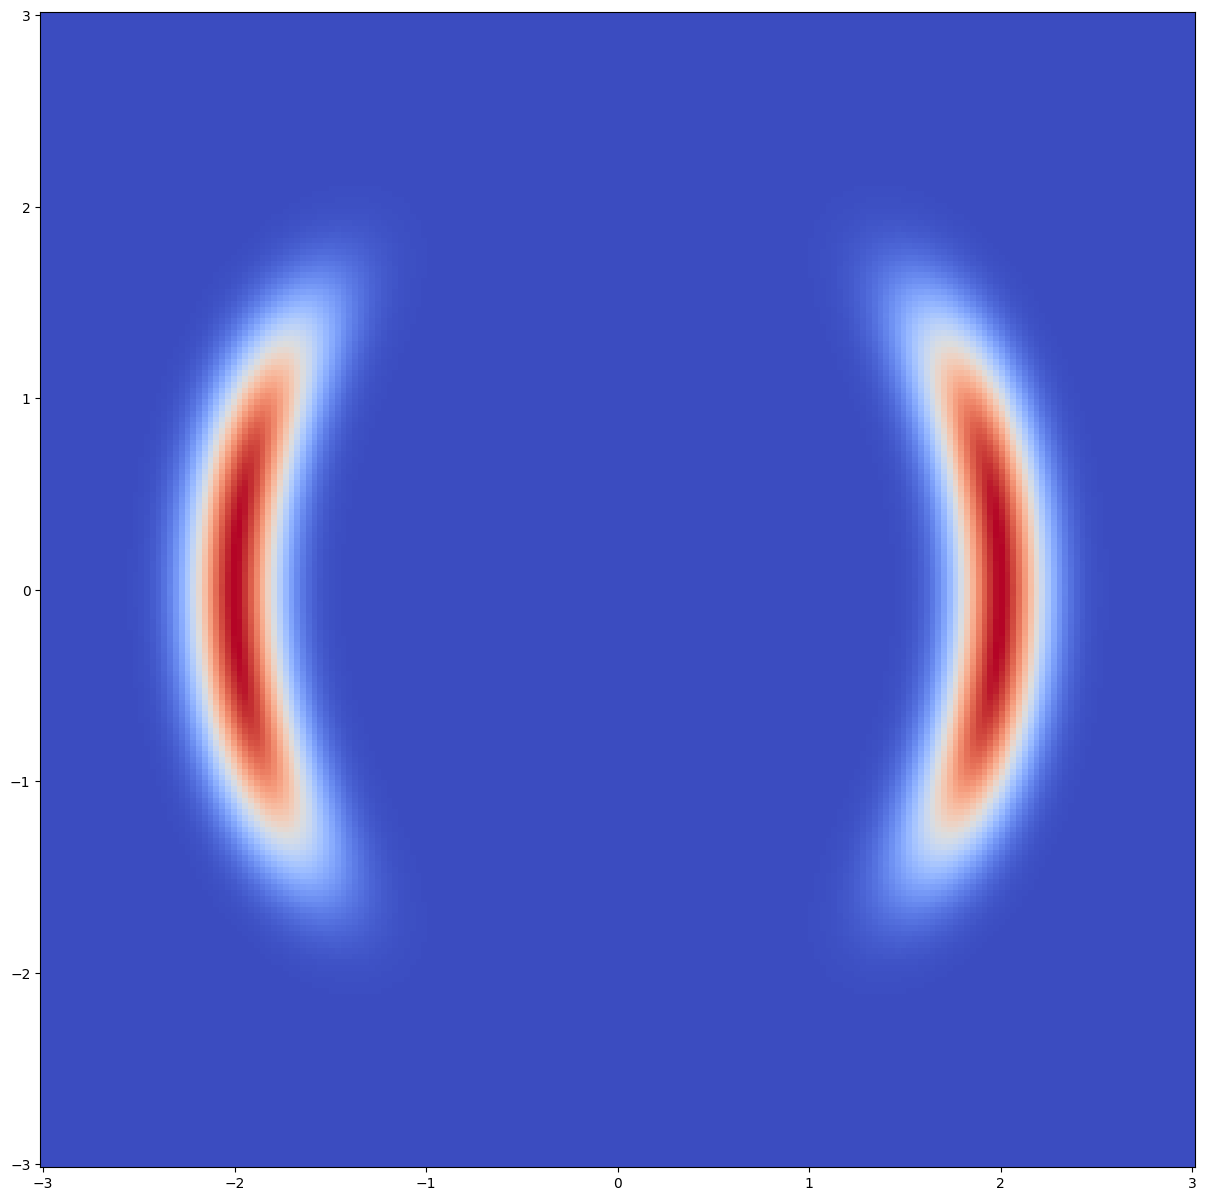

In [29]:
# Set up model
# 1. Definir una capa de acoplamiento NICE personalizada
class NiceCoupling(nf.flows.AffineCouplingBlock):
    def __init__(self, param_map, input_dim=2):
        super().__init__(param_map, scale_map=None)
        self.d = input_dim // 2
        self.param_map = param_map  # Registrar explícitamente el param_map

    def split(self, x):
        return x[:, :self.d], x[:, self.d:]

    def forward(self, z):
        z1, z2 = self.split(z)
        shift = self.param_map(z1)  # Acceder al param_map registrado
        y2 = z2 + shift
        y = torch.cat([z1, y2], dim=1)
        return y, torch.zeros(z.shape[0], device=z.device)

    def inverse(self, y):
        y1, y2 = self.split(y)
        shift = self.param_map(y1)
        z2 = y2 - shift
        z = torch.cat([y1, z2], dim=1)
        return z, torch.zeros(y.shape[0], device=y.device)



# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)

# Define list of flows
flows = []
num_layers = 32

for _ in range(num_layers):
    # Red neuronal solo para el desplazamiento (1 output)
    param_map = nf.nets.MLP([1, 64, 64, 1], init_zeros=True)
    # Usar nuestra capa personalizada
    flows.append(NiceCoupling(param_map, input_dim=2))
    flows.append(nf.flows.Permute(2, mode='swap'))

# Construct flow model
model = nf.NormalizingFlow(base, flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

#######################################################################
###                 Target Distribution                     ###########
#######################################################################
# Define target distribution
target = nf.distributions.TwoMoons()

# Plot target distribution
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-3, 3, grid_size), torch.linspace(-3, 3, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()


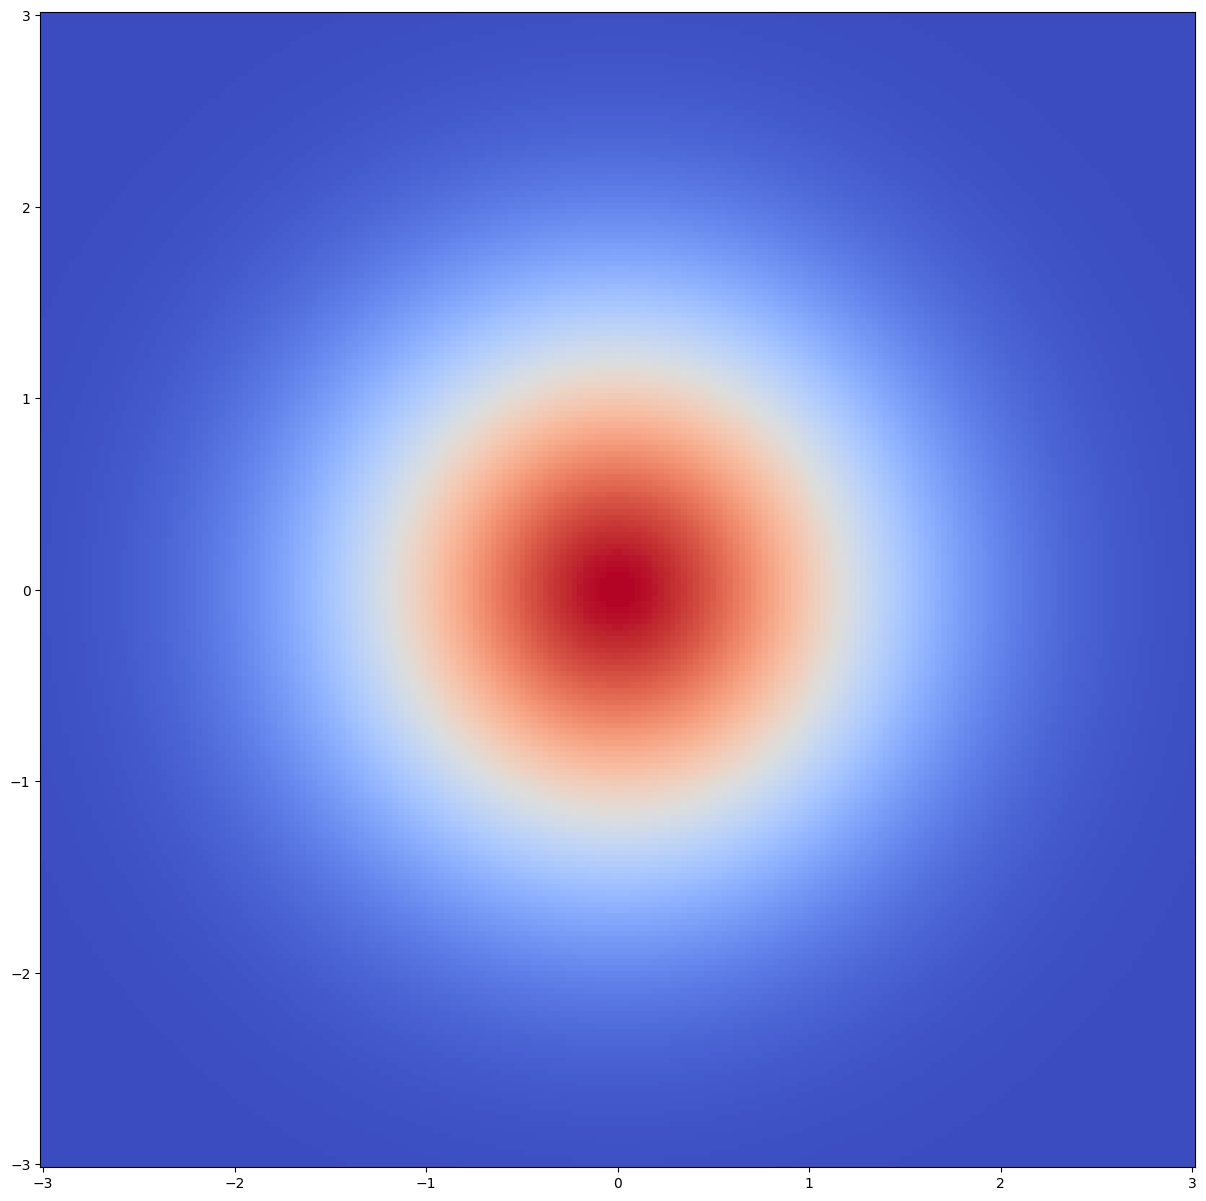

In [30]:
# Plot initial flow distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()


 50%|████▉     | 498/1000 [00:33<00:25, 20.00it/s]

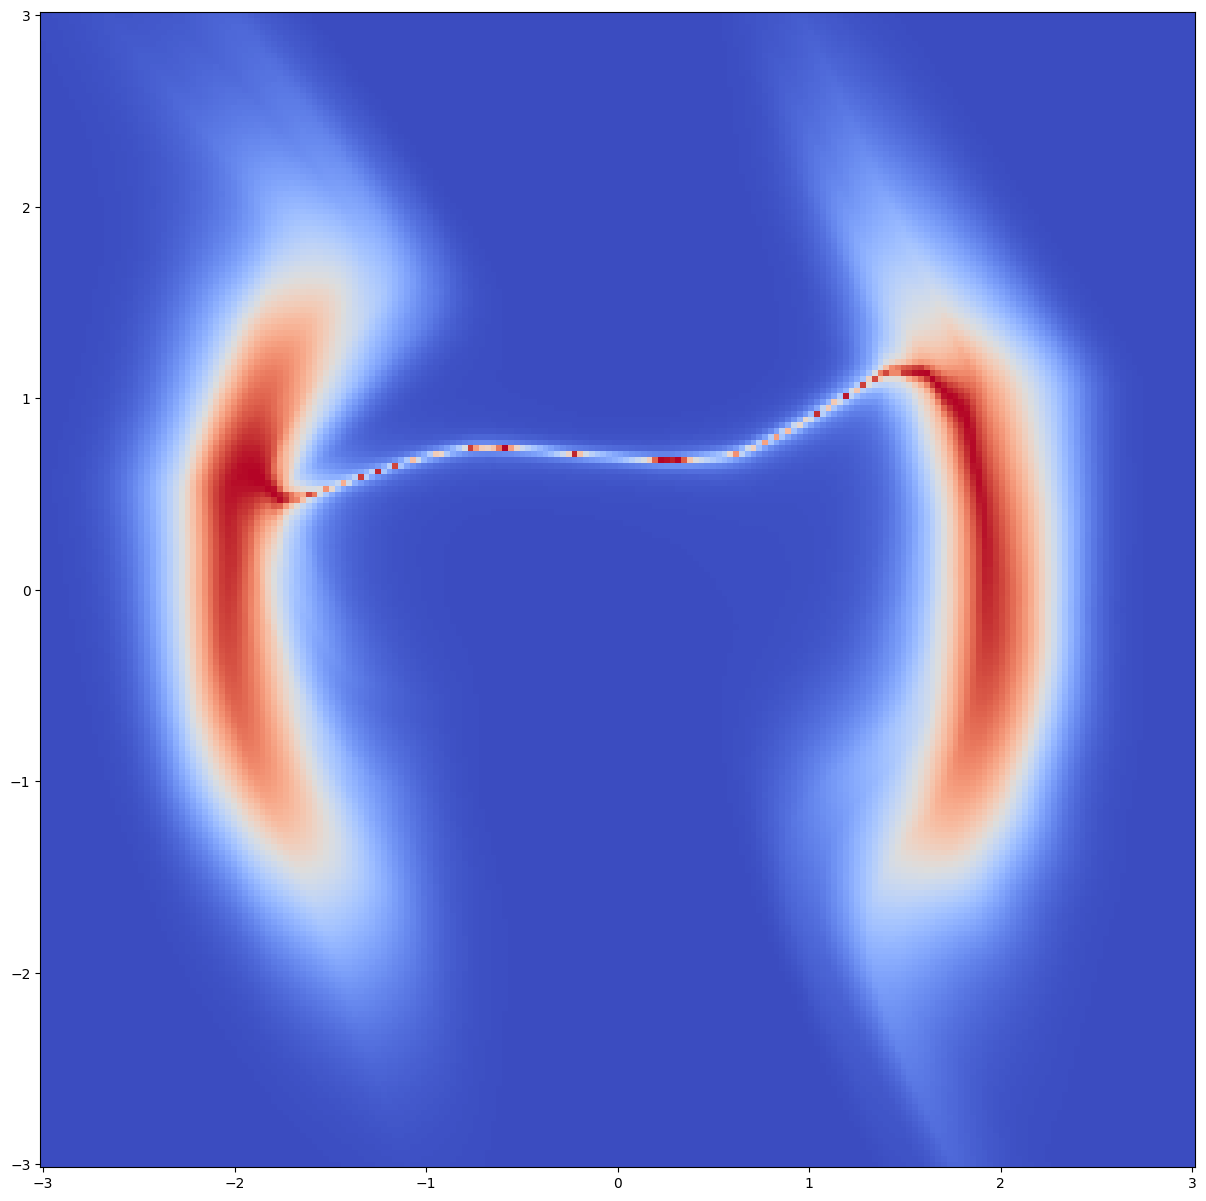

100%|█████████▉| 999/1000 [01:03<00:00, 20.56it/s]

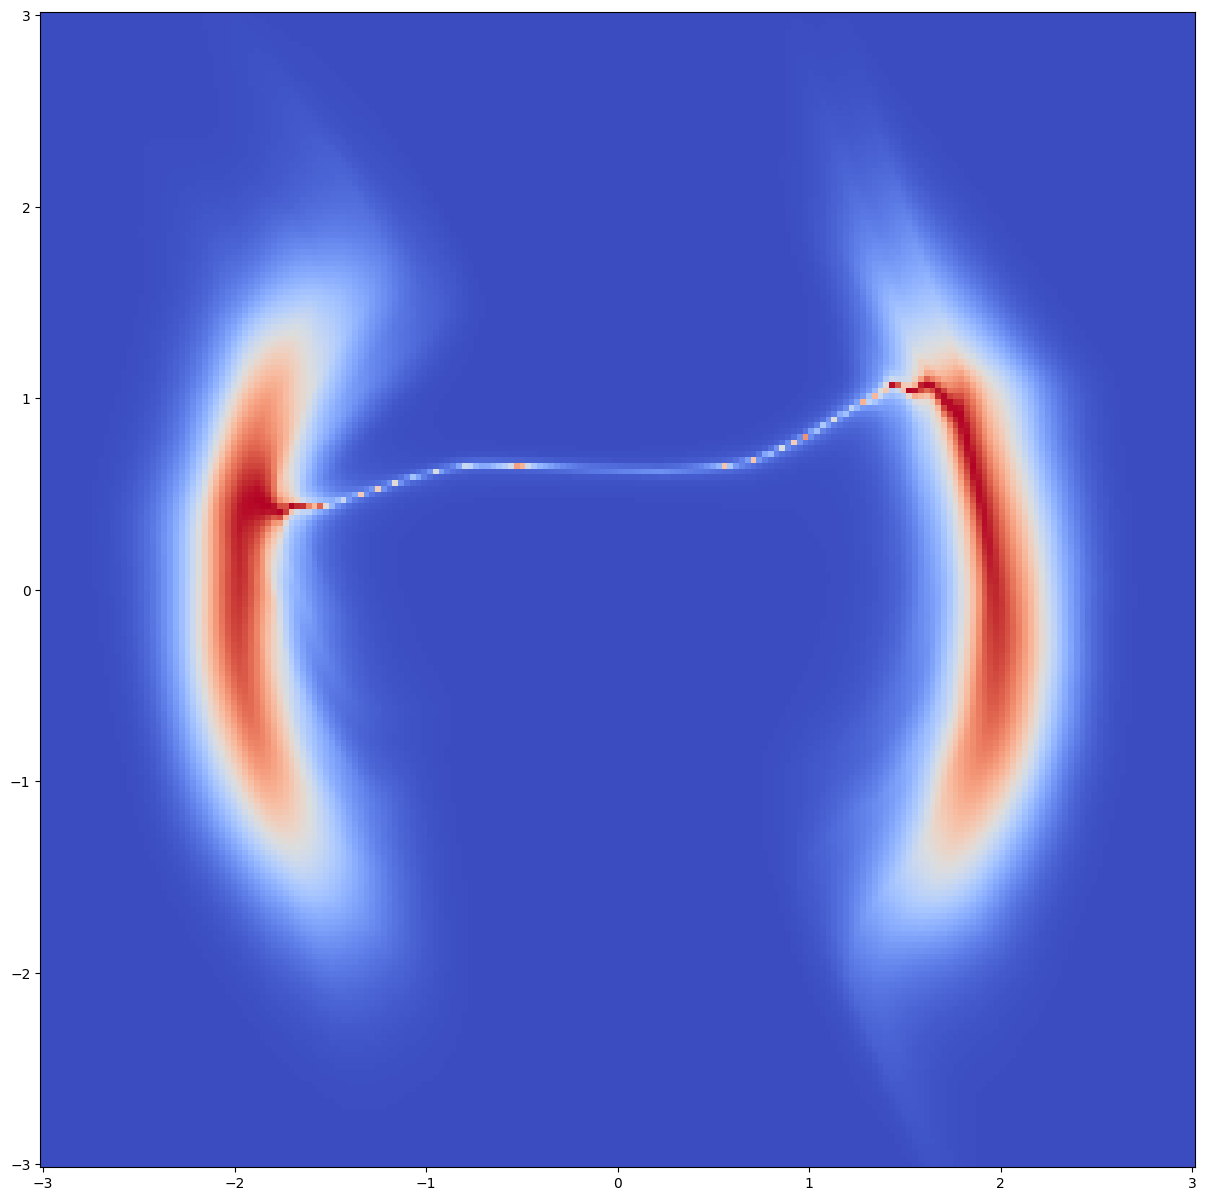

100%|██████████| 1000/1000 [01:04<00:00, 15.57it/s]


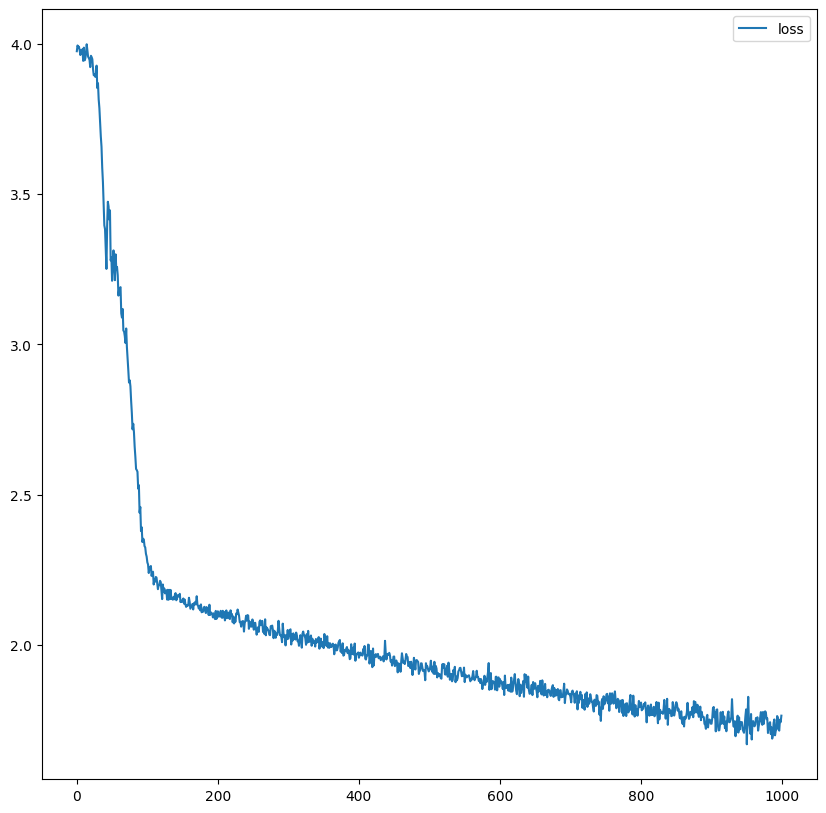

In [31]:
# Train model
max_iter = 1000
num_samples = 2 ** 9
show_iter = 500


loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Get training samples
    x = target.sample(num_samples).to(device)

    # Compute loss
    loss = model.forward_kld(x)

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
        # Plot learned distribution
    if (it + 1) % show_iter == 0:
        model.eval()
        log_prob = model.log_prob(zz)
        model.train()
        prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        prob[torch.isnan(prob)] = 0

        plt.figure(figsize=(15, 15))
        plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
        plt.gca().set_aspect('equal', 'box')
        plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


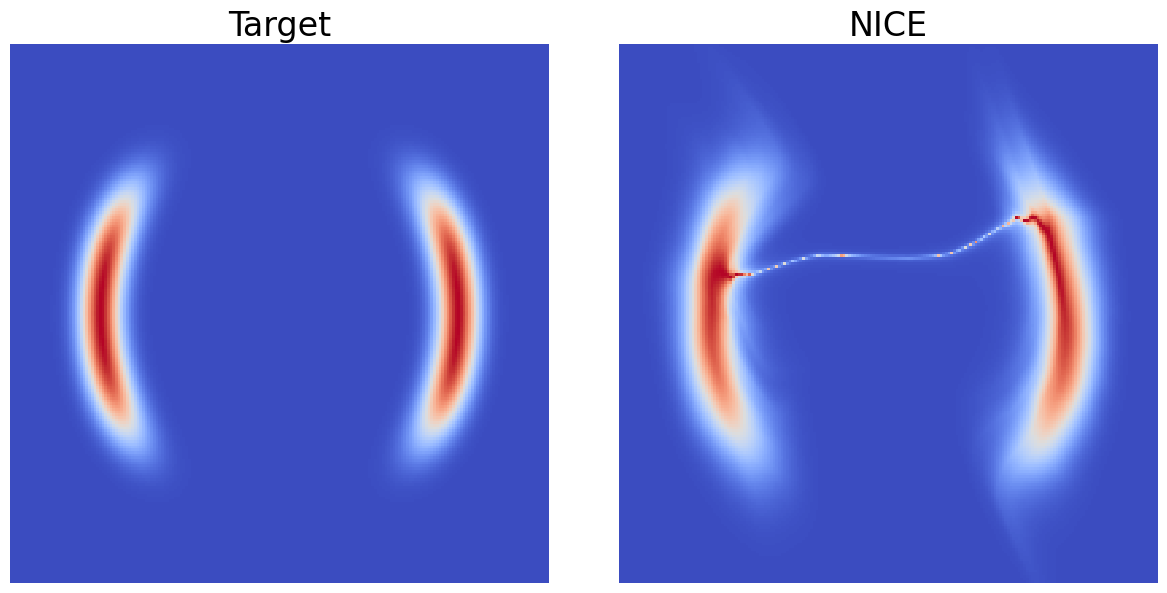

In [32]:
# Plot target distribution
f, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 7))

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[0].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[0].set_aspect('equal', 'box')
ax[0].set_axis_off()
ax[0].set_title('Target', fontsize=24)

# Plot learned distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[1].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[1].set_aspect('equal', 'box')
ax[1].set_axis_off()
ax[1].set_title('NICE', fontsize=24)

plt.subplots_adjust(wspace=0.1)

plt.show()


#Real_NVP

1. Capa de Acoplamiento Afín (Affine Coupling Layer)

En Real NVP, la transformación se realiza mediante capas de acoplamiento afín. Para un vector $\mathbf{x}$, se divide en dos partes:

$$
\mathbf{x}=\left[\mathbf{x}_1, \mathbf{x}_2\right], \quad \text { donde } \mathbf{x}_1 \in \mathbb{R}^d, \mathbf{x}_2 \in \mathbb{R}^{D-d} .
$$


Transformación Directa ( $\mathbf{x} \rightarrow \mathbf{y}$ ):

$$
\left\{\begin{array}{l}
\mathbf{y}_1=\mathbf{x}_1 \\
\mathbf{y}_2=\mathbf{x}_2 \odot \exp \left(s\left(\mathbf{x}_1\right)\right)+t\left(\mathbf{x}_1\right)
\end{array}\right.
$$

donde:
- $s(\cdot)$ y $t(\cdot)$ son redes neuronales (scale y shift).
- $\bigcirc$ denota el producto elemento a elemento (Hadamard).

Inversa ( $\mathbf{y} \rightarrow \mathbf{x}$ ):

$$
\left\{\begin{array}{l}
\mathbf{x}_1=\mathbf{y}_1 \\
\mathbf{x}_2=\left(\mathbf{y}_2-t\left(\mathbf{y}_1\right)\right) \odot \exp \left(-s\left(\mathbf{y}_1\right)\right) .
\end{array}\right.
$$

2. Log-Determinante del Jacobiano

El Jacobiano de la transformación es triangular inferior:

$$
\frac{\partial \mathbf{y}}{\partial \mathbf{x}}=\left[\begin{array}{cc}
I & 0 \\
\frac{\partial \mathbf{y}_2}{\partial \mathbf{x}_1} & \operatorname{diag}\left(\exp \left(s\left(\mathbf{x}_1\right)\right)\right)
\end{array}\right] .
$$


El log-determinante es:

$$
\log \left|\operatorname{det} \frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right|=\sum_{i=1}^{D-d} s_i\left(\mathbf{x}_1\right)
$$

donde $s_i$ son las salidas de la red $s(\cdot)$.

In [ ]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


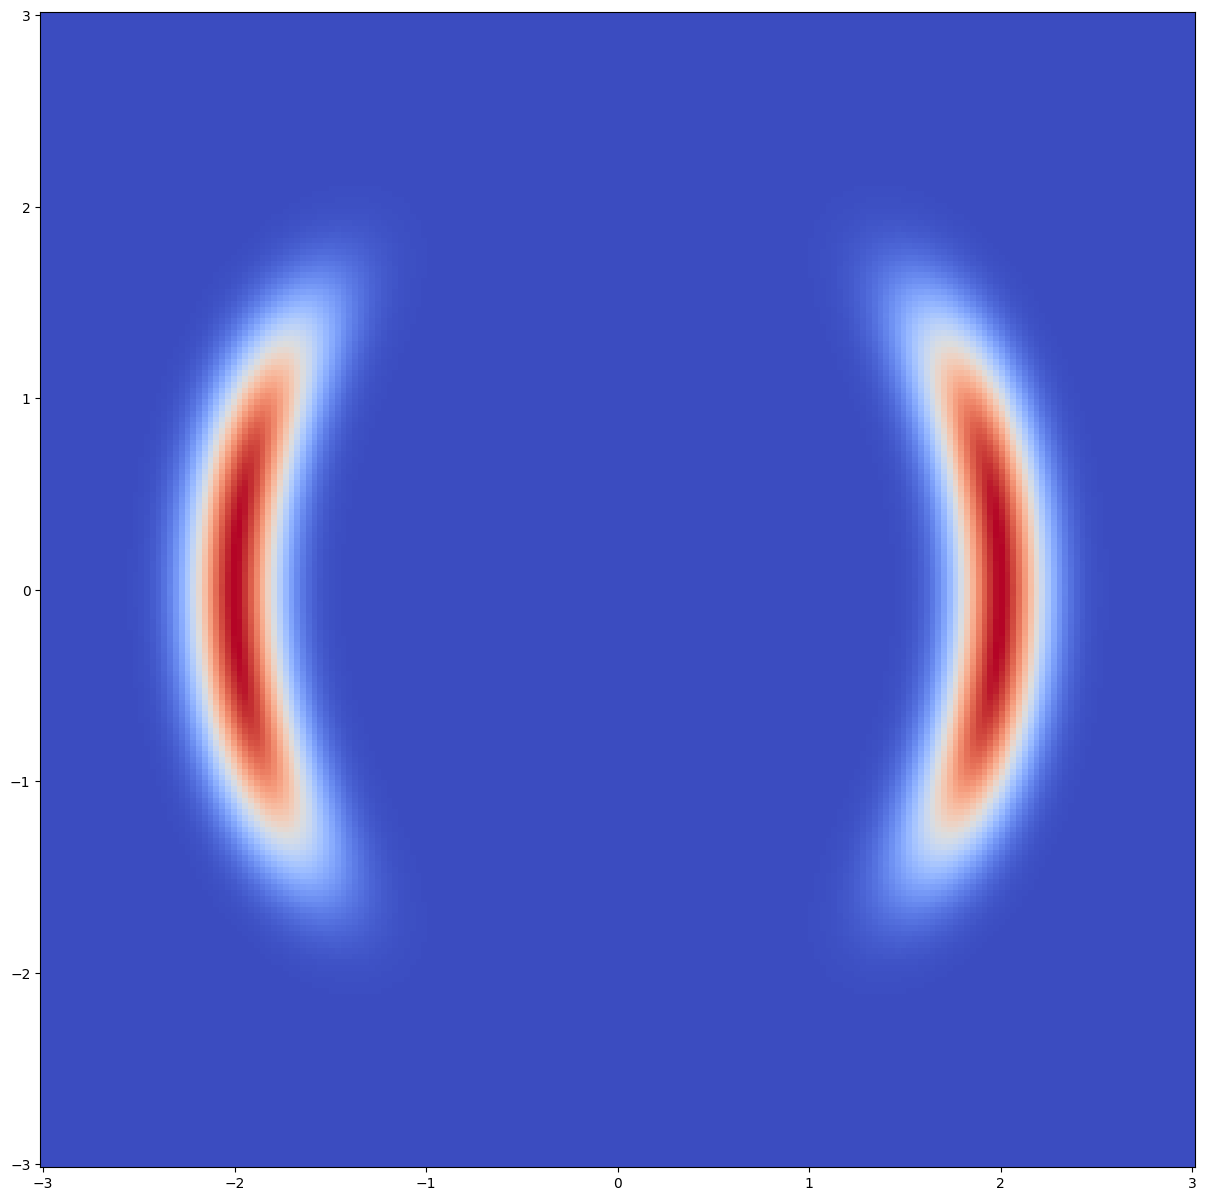

In [ ]:
# Set up model

# Define 2D Gaussian base distribution
base = nf.distributions.base.DiagGaussian(2)

# Define list of flows
num_layers = 32
flows = []
for i in range(num_layers):
    # Neural network with two hidden layers having 64 units each
    # Last layer is initialized by zeros making training more stable
    param_map = nf.nets.MLP([1, 64, 64, 2], init_zeros=True)
    # Add flow layer
    flows.append(nf.flows.AffineCouplingBlock(param_map))
    # Swap dimensions
    flows.append(nf.flows.Permute(2, mode='swap'))

# Construct flow model
model = nf.NormalizingFlow(base, flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

#######################################################################
###                 Target Distribution                     ###########
#######################################################################
# Define target distribution
target = nf.distributions.TwoMoons()

# Plot target distribution
grid_size = 200
xx, yy = torch.meshgrid(torch.linspace(-3, 3, grid_size), torch.linspace(-3, 3, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()


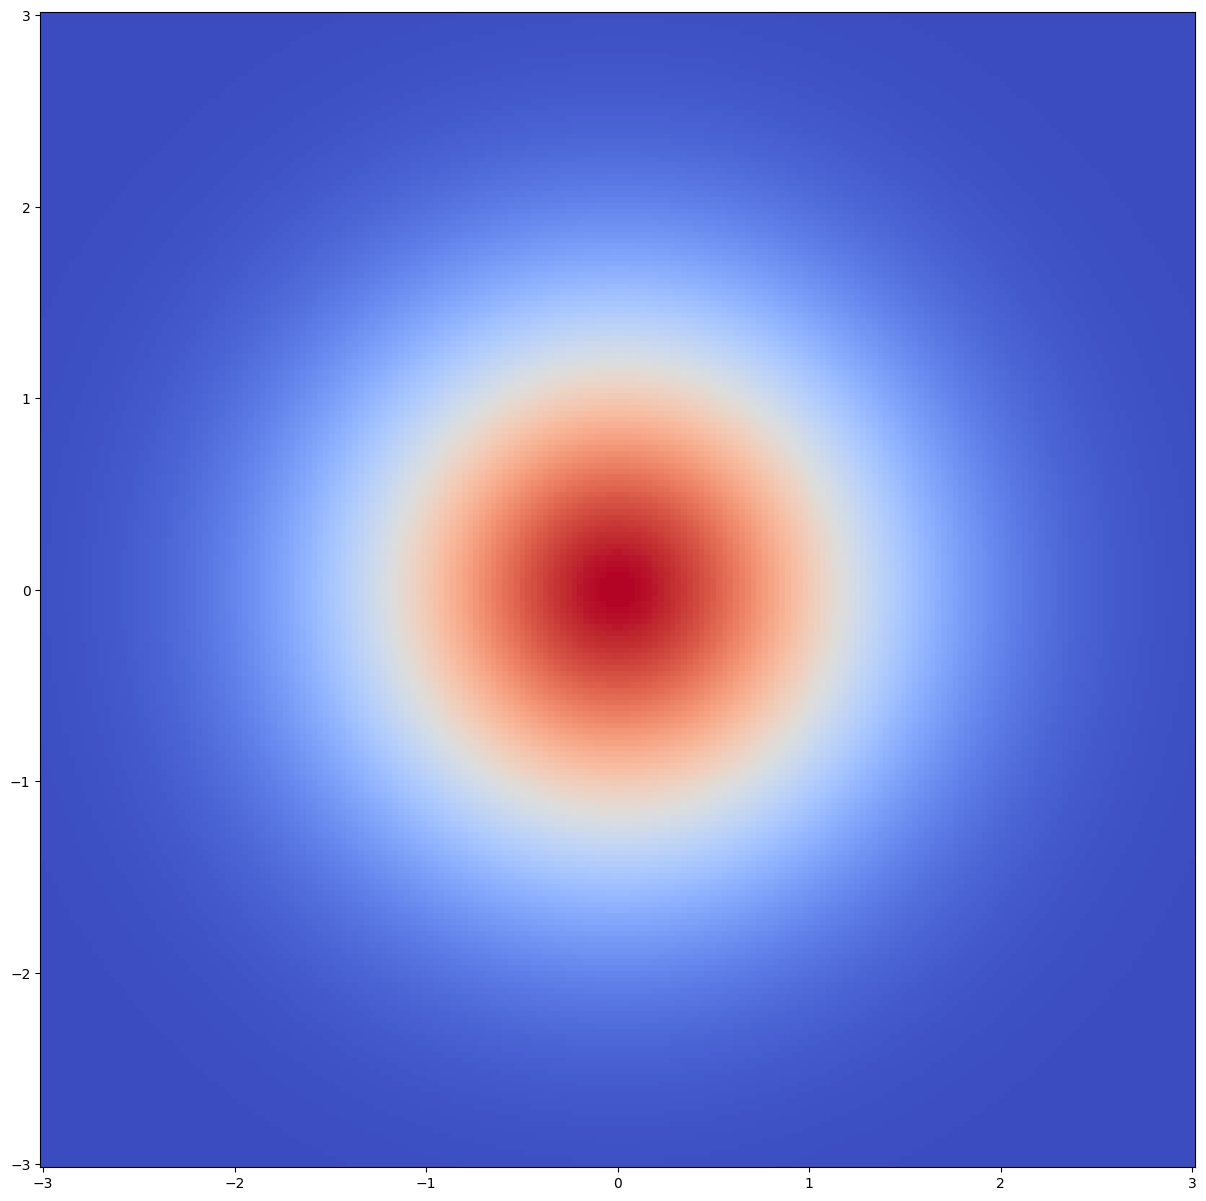

In [ ]:
# Plot initial flow distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
plt.gca().set_aspect('equal', 'box')
plt.show()


 12%|█▏        | 498/4000 [00:42<04:37, 12.61it/s]

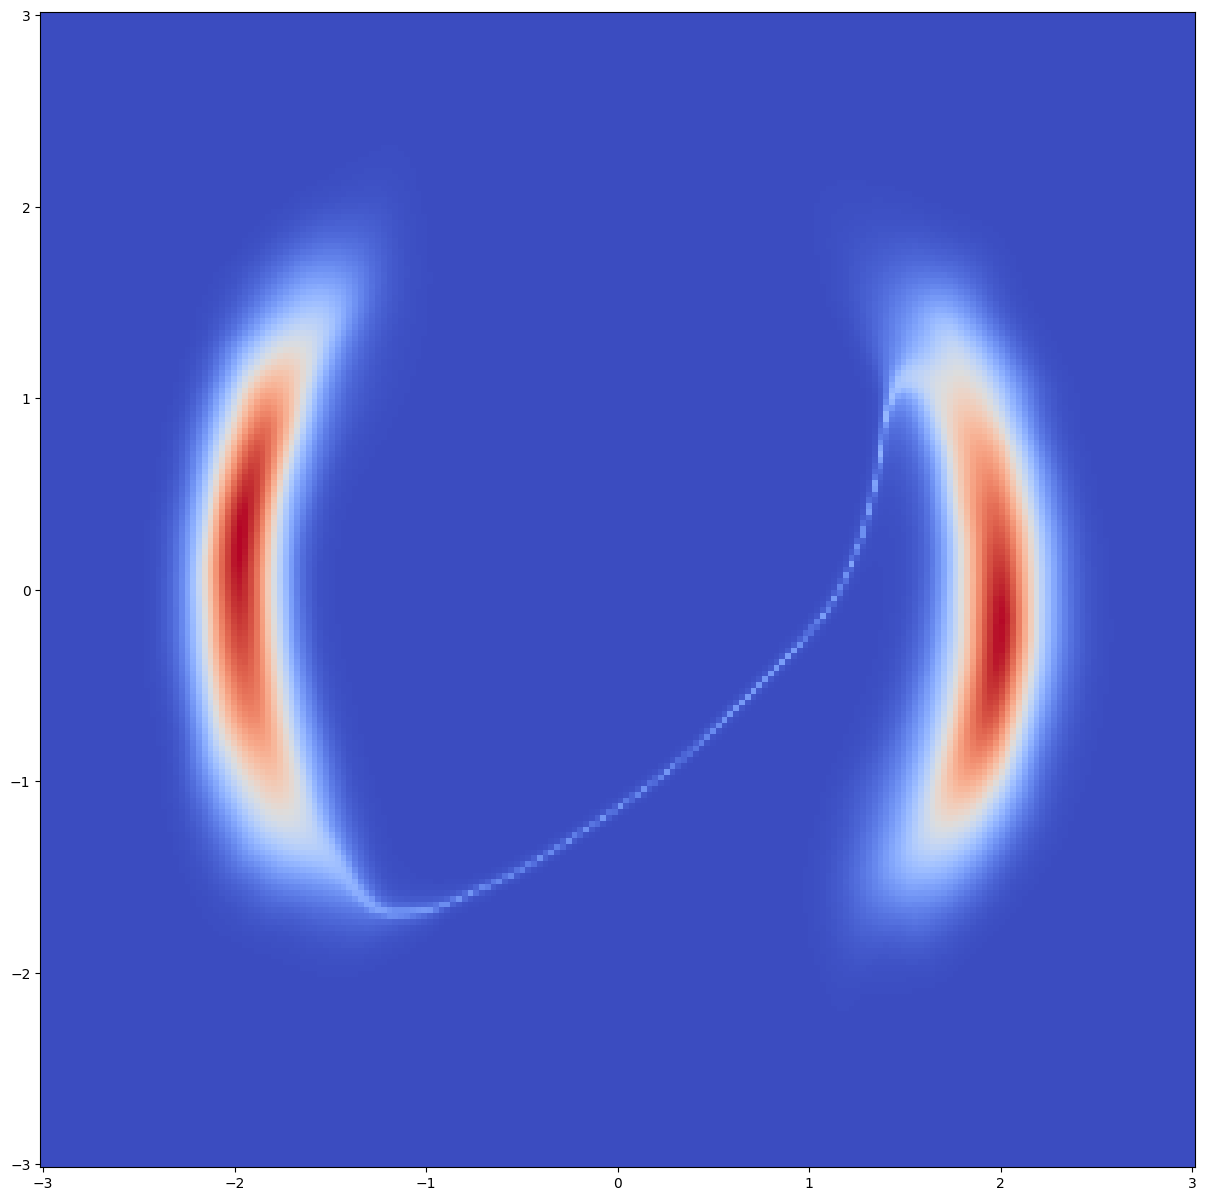

 25%|██▍       | 998/4000 [01:24<03:16, 15.31it/s]

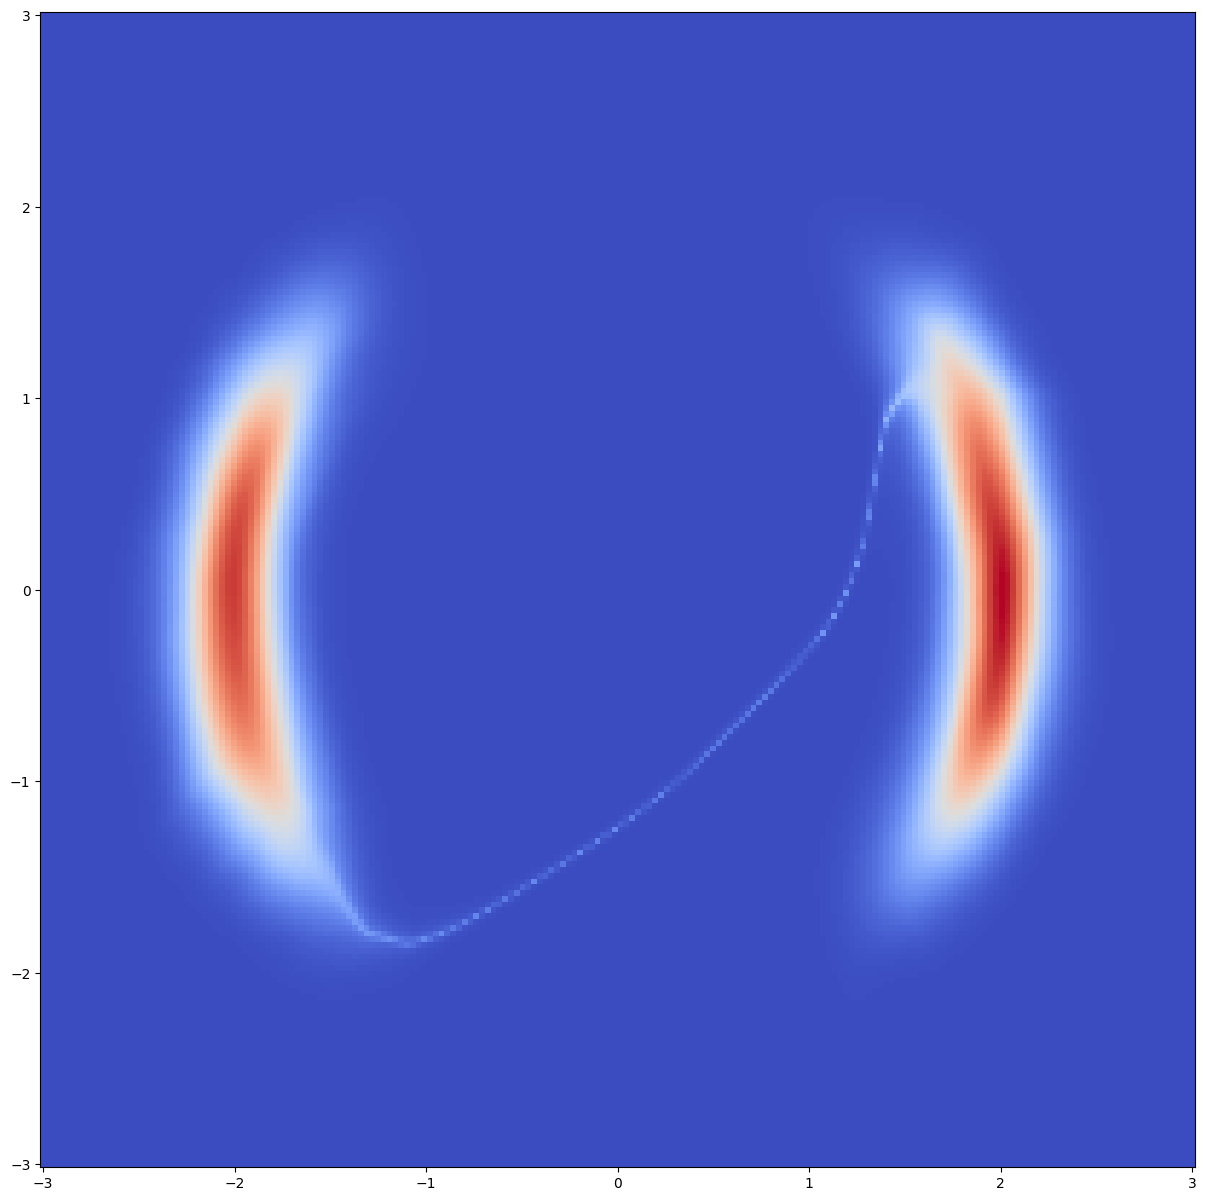

 37%|███▋      | 1498/4000 [02:03<03:08, 13.28it/s]

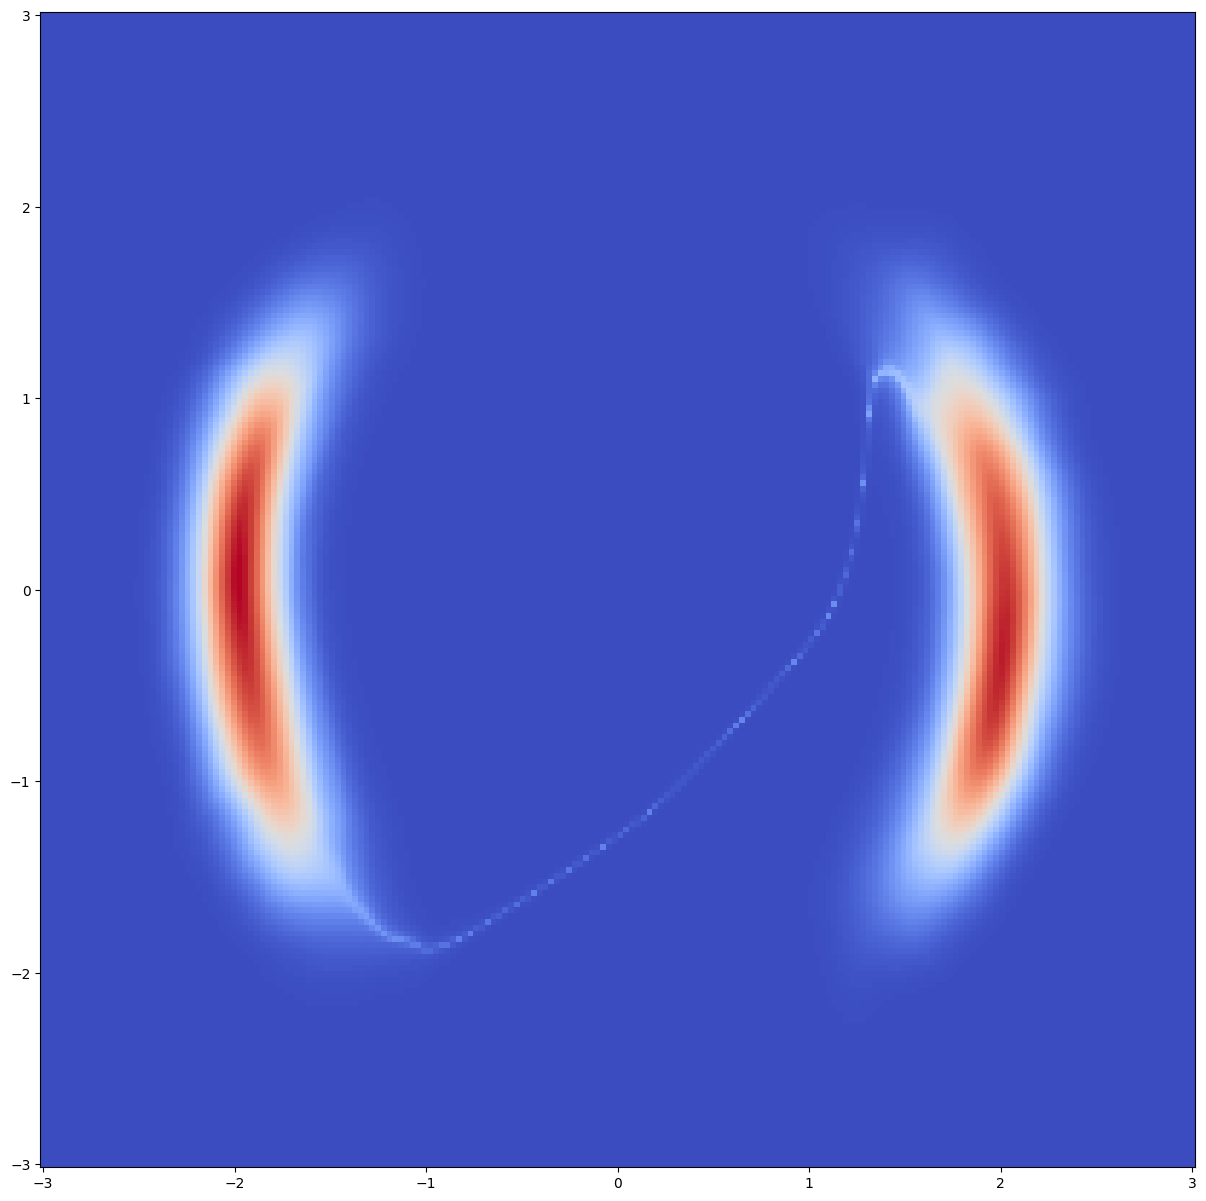

 50%|████▉     | 1999/4000 [03:02<03:54,  8.54it/s]

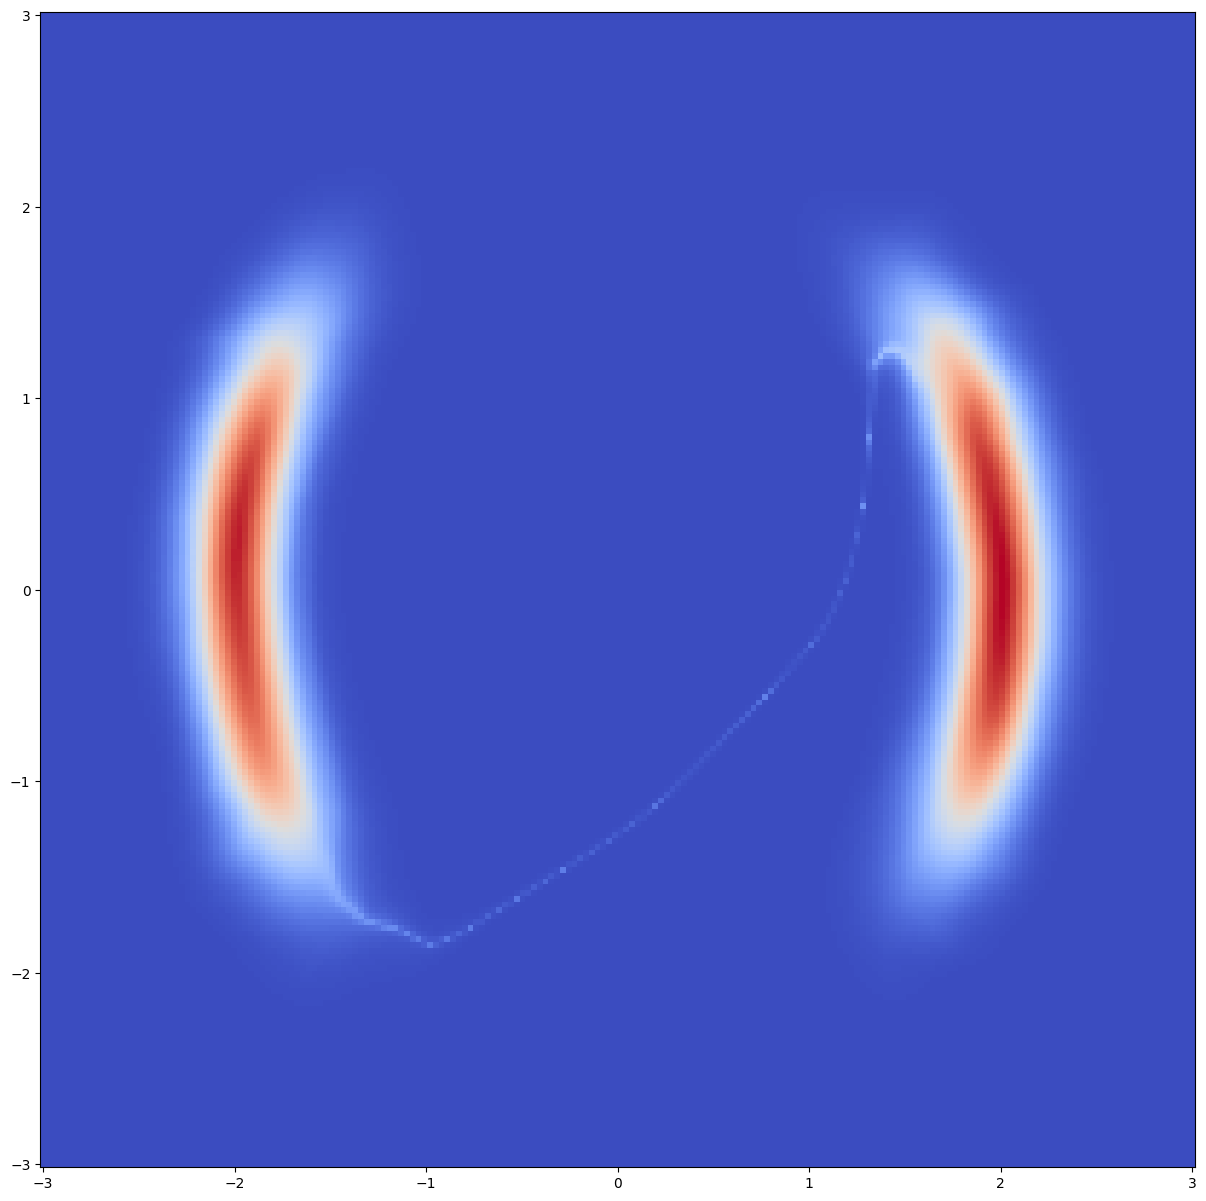

 62%|██████▏   | 2499/4000 [04:17<04:16,  5.85it/s]

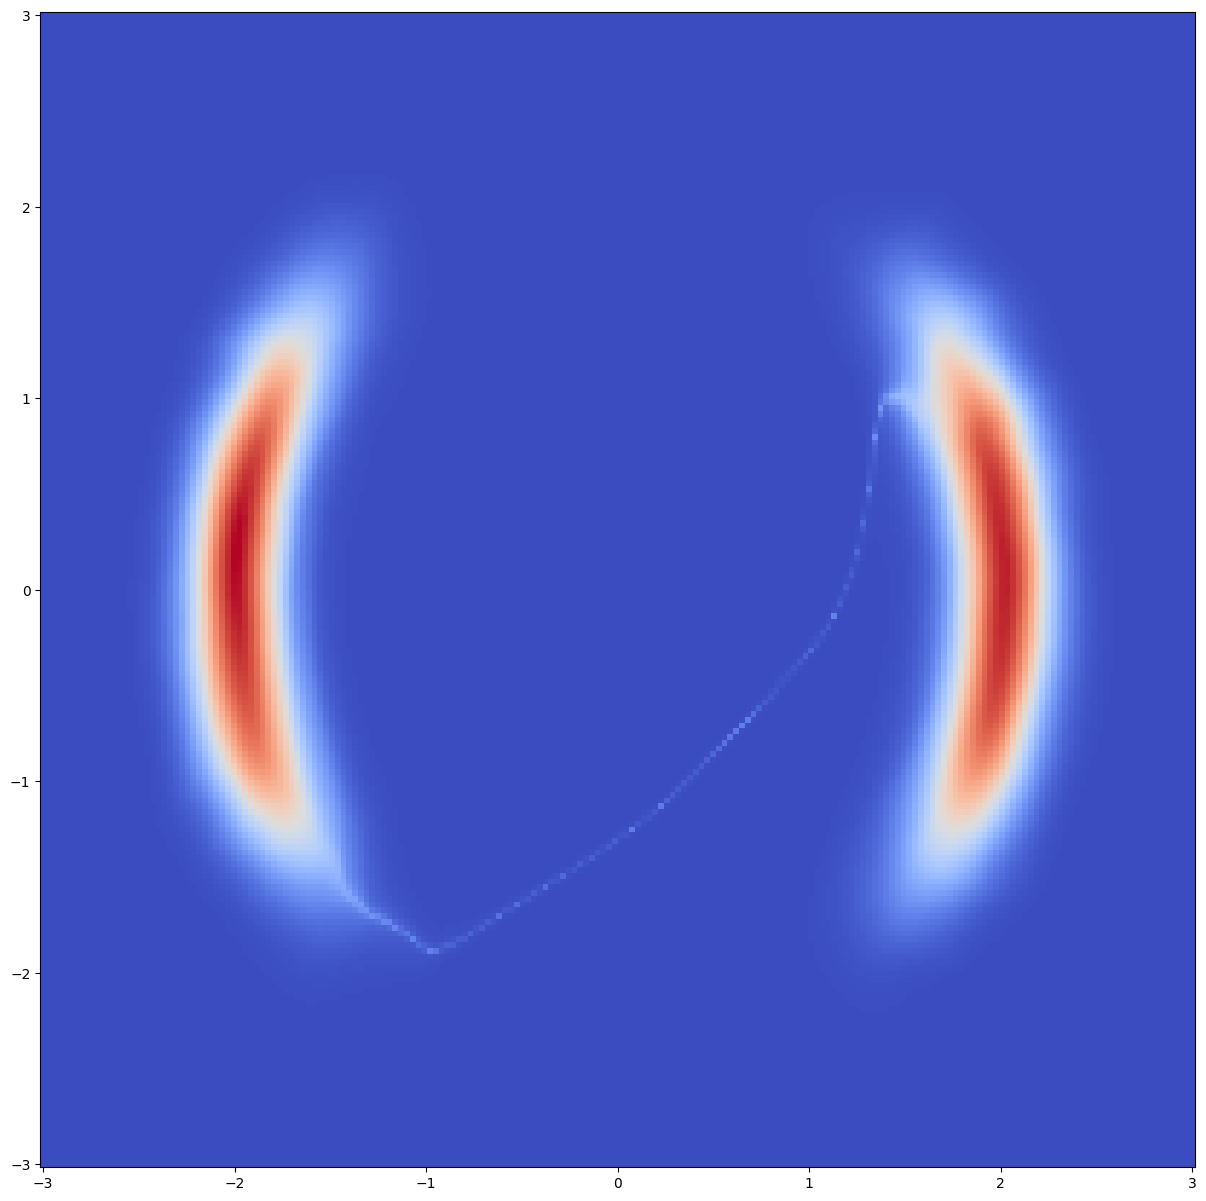

 75%|███████▍  | 2999/4000 [06:14<03:14,  5.14it/s]

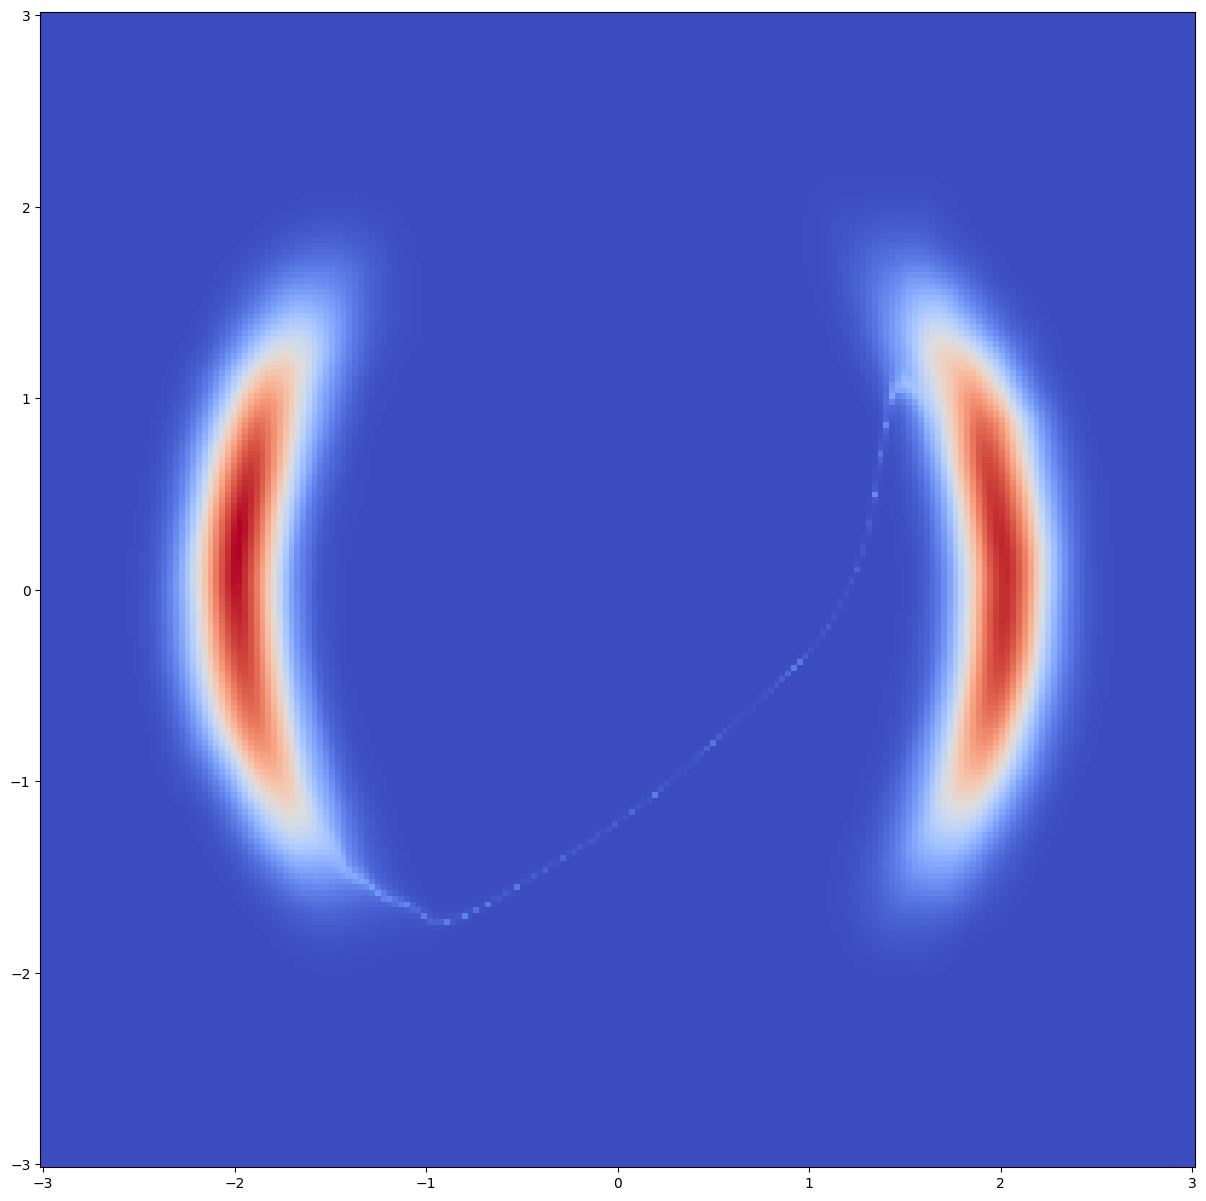

 87%|████████▋ | 3499/4000 [08:03<02:47,  2.99it/s]

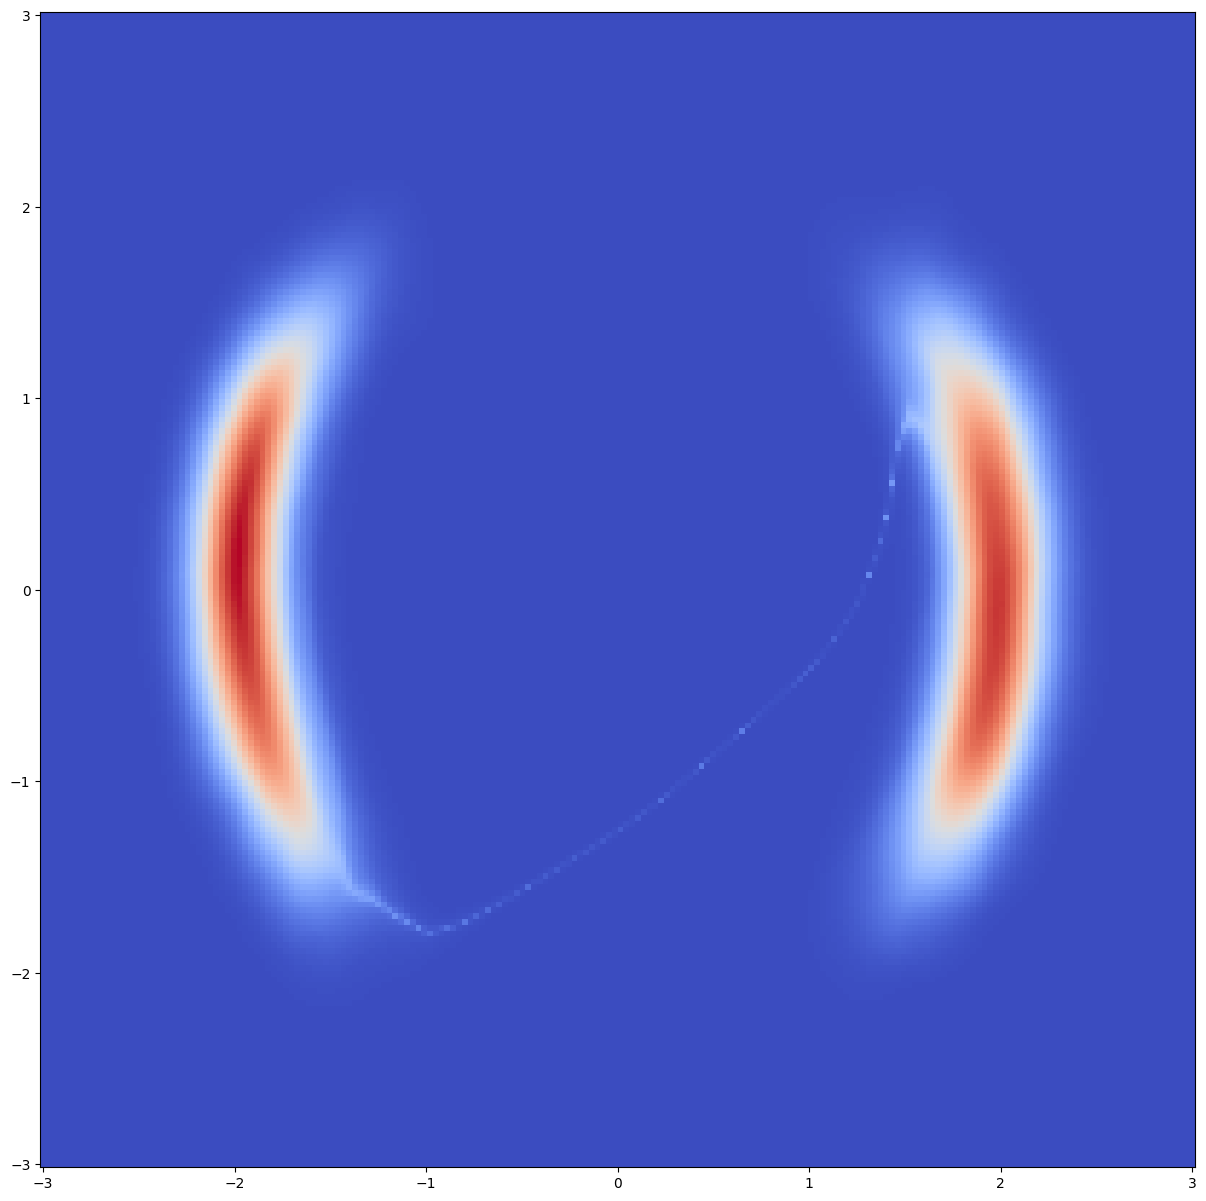

100%|█████████▉| 3999/4000 [09:47<00:00,  5.47it/s]

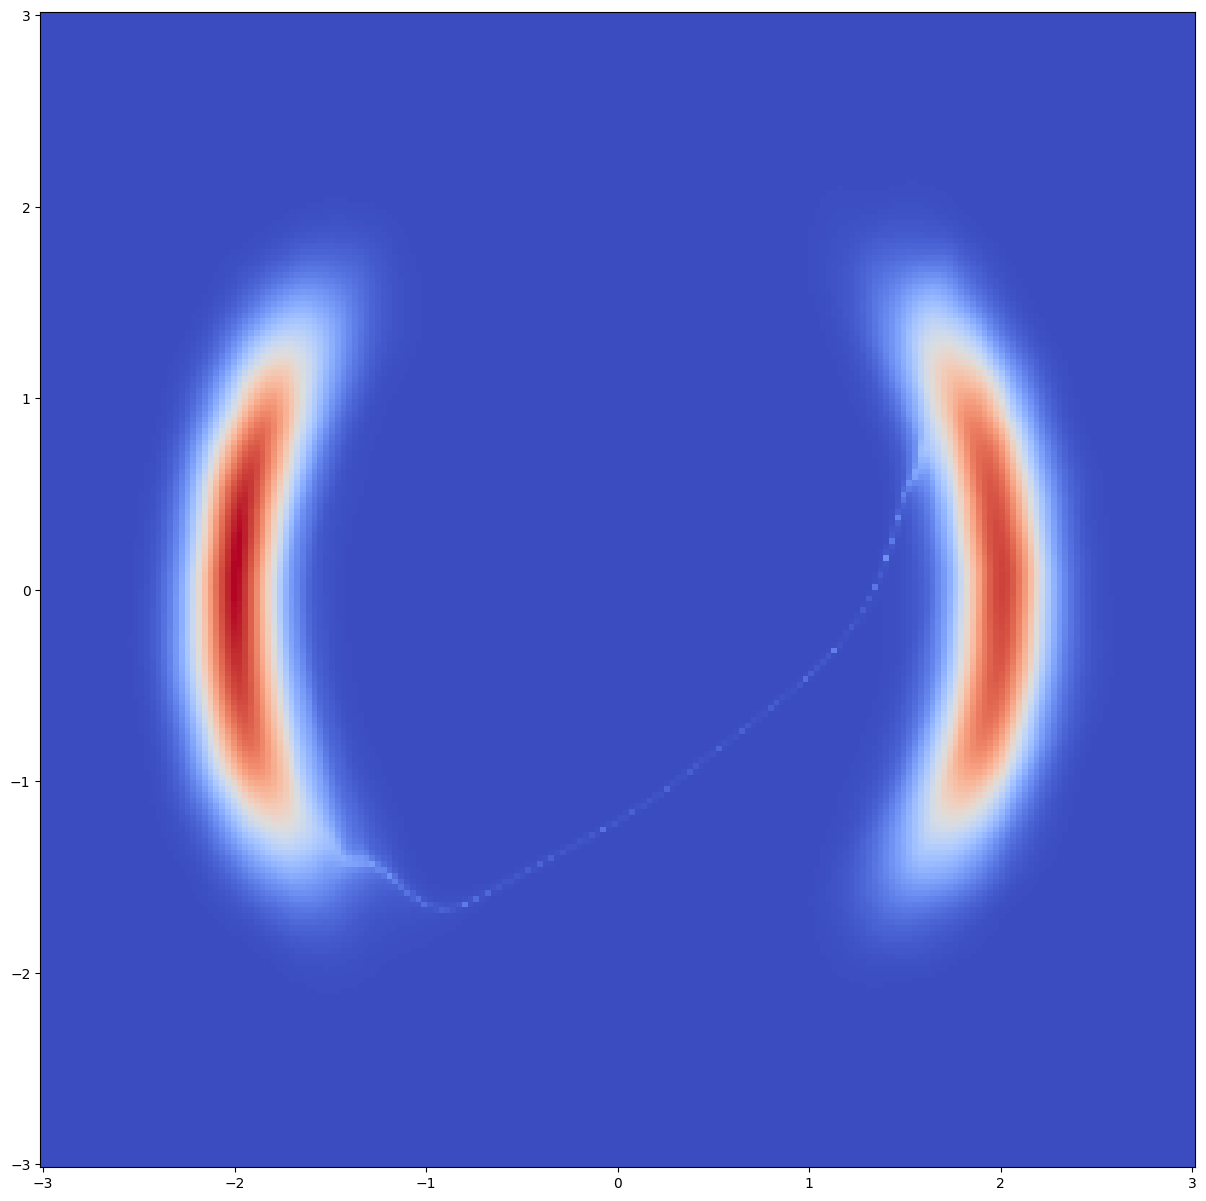

100%|██████████| 4000/4000 [09:49<00:00,  6.78it/s]


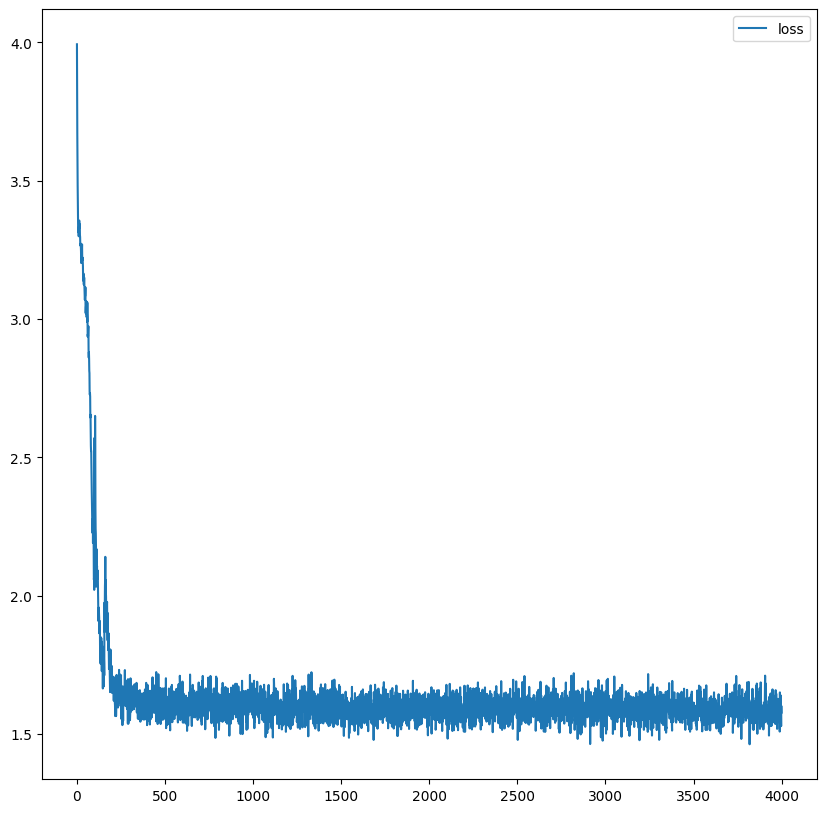

In [ ]:
# Train model
max_iter = 4000
num_samples = 2 ** 9
show_iter = 500


loss_hist = np.array([])

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-5)

for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Get training samples
    x = target.sample(num_samples).to(device)

    # Compute loss
    loss = model.forward_kld(x)

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())
        # Plot learned distribution
    if (it + 1) % show_iter == 0:
        model.eval()
        log_prob = model.log_prob(zz)
        model.train()
        prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        prob[torch.isnan(prob)] = 0

        plt.figure(figsize=(15, 15))
        plt.pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')
        plt.gca().set_aspect('equal', 'box')
        plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()


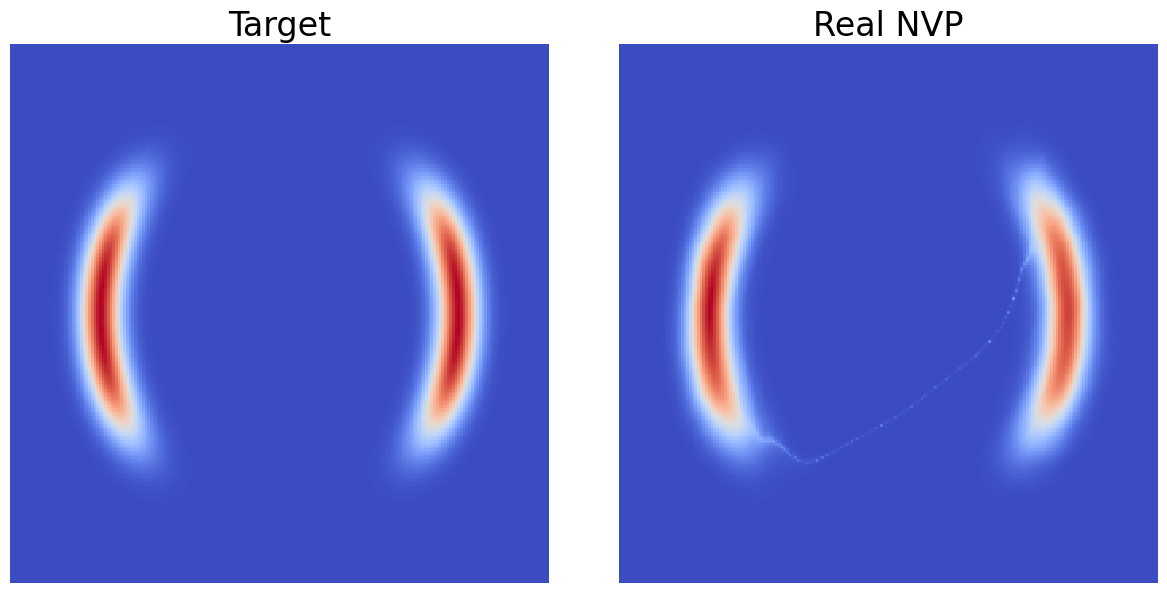

In [ ]:
# Plot target distribution
f, ax = plt.subplots(1, 2, sharey=True, figsize=(15, 7))

log_prob = target.log_prob(zz).to('cpu').view(*xx.shape)
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[0].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[0].set_aspect('equal', 'box')
ax[0].set_axis_off()
ax[0].set_title('Target', fontsize=24)

# Plot learned distribution
model.eval()
log_prob = model.log_prob(zz).to('cpu').view(*xx.shape)
model.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

ax[1].pcolormesh(xx, yy, prob.data.numpy(), cmap='coolwarm')

ax[1].set_aspect('equal', 'box')
ax[1].set_axis_off()
ax[1].set_title('Real NVP', fontsize=24)

plt.subplots_adjust(wspace=0.1)

plt.show()


#Glow

Glow extiende los principios de NICE y RealNVP al introducir convoluciones invertibles 1×1 y una arquitectura multi-escala para generación de imágenes de alta resolución. A continuación, sus componentes clave:

1. Capa de Convolución Invertible 1×1 (Forward Pass): Reemplaza las permutaciones estáticas de NICE/RealNVP con una transformación lineal aprendible para mezclar canales en datos de imagen:

  Para una entrada $x \in \mathbb{R}^{CxHxW}$
  (canales, altura, ancho):
  \begin{equation}
  \mathbf{y} = \mathbf{W} \mathbf{x}, \quad \mathbf{W} \in \mathbb{R}^{C \times C} \text{ (matriz invertible)}
  \end{equation}

  **Implementación práctica**:

  Factorización LU para garantizar invertibilidad y cálculo eficiente del determinante:
  \begin{equation}
  \mathbf{W} = \mathbf{P} \mathbf{L} (\mathbf{U} + \mathrm{diag}(\mathbf{s}))
  \end{equation}
  donde P es una matriz de permutación, L (triangular inferior), U (triangular superior), y s (vector de escala).


2. Capa de Acoplamiento Afín (Affine Coupling): Amplía las transformaciones aditivas de NICE al incorporar escalado y desplazamiento:

  Partición de la entrada: $x=[x_1,x_2]$(e.g., canales pares/impares).

  **Transformación forward**:
  \begin{align}
  \mathbf{y}_1 = \mathbf{x}_1 \
  \mathbf{y}_2 = \mathbf{x}_2 \odot \exp\left(s(\mathbf{x}_1)\right) + t(\mathbf{x}_1)
  \end{align}
  donde $s(⋅)$ y $t(⋅)$ son redes convolucionales.

  **Inversa**:
  \begin{align}
  \mathbf{x}_1 = \mathbf{y}_1 \
  \mathbf{x}_2 = \left(\mathbf{y}_2 - t(\mathbf{y}_1)\right) \odot \exp\left(-s(\mathbf{y}_1)\right)
  \end{align}

3. Log-Determinante del Jacobiano
Glow relaja la restricción de preservación de volumen de NICE, permitiendo cambios controlados:

  Para la convolución 1×1:
  \begin{equation}
  \log \left|\det \frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right| = H \cdot W \cdot \log|\det \mathbf{W}|
  \end{equation}

  Para la capa afín:
  \begin{equation}
  \log \left|\det \frac{\partial \mathbf{y}}{\partial \mathbf{x}}\right| = \sum_{i} s(\mathbf{x}_1)_i
  \end{equation}

4. Arquitectura Multi-Escala
Estructura jerárquica para manejar alta dimensionalidad en imágenes:

  Squeeze: Reorganiza espacialmente los canales (e.g., de $C×H×W$ a $4C×H/2×W/2$).

  Flujo: Aplica bloques de convolución 1×1 + acoplamiento afín.

  Split: Divide la mitad de los canales en el espacio latente (reduciendo progresivamente la resolución).

In [ ]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

In [ ]:
# Set up model

# Define flows
L = 3 #niveles de flujo
K = 16 #bloques Glow (conv + acople)
torch.manual_seed(0)

input_shape = (3, 32, 32)
n_dims = np.prod(input_shape)
channels = 3
hidden_channels = 256
split_mode = 'channel'
scale = True
num_classes = 10

# Set up flows, distributions and merge operations
q0 = [] # Distribuciones latentes iniciales por nivel
merges = [] # Operaciones de fusión entre niveles
flows = [] # Bloques de flujo por nivel

for i in range(L): # Para cada nivel de resolución (L niveles)
    flows_ = []
    for j in range(K): # Añade K bloques Glow por nivel
        flows_ += [nf.flows.GlowBlock(channels * 2 ** (L + 1 - i), hidden_channels,
                                     split_mode=split_mode, scale=scale)]
    flows_ += [nf.flows.Squeeze()]
    flows += [flows_]

    # Define la forma latente según el nivel
    if i > 0:
        merges += [nf.flows.Merge()]# Combina variables latentes
        latent_shape = (input_shape[0] * 2 ** (L - i), input_shape[1] // 2 ** (L - i),
                        input_shape[2] // 2 ** (L - i))
    else:
        latent_shape = (input_shape[0] * 2 ** (L + 1), input_shape[1] // 2 ** L,
                        input_shape[2] // 2 ** L)
    q0 += [nf.distributions.ClassCondDiagGaussian(latent_shape, num_classes)]# Gaussiana por nivel


# Construct flow model with the multiscale architecture
model = nf.MultiscaleFlow(q0, flows, merges) #compacta el modelo de NF

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torch/_tensor.py:902: UserWarning: torch.lu is deprecated in favor of torch.linalg.lu_factor / torch.linalg.lu_factor_ex and will be removed in a future PyTorch release.
LU, pivots = torch.lu(A, compute_pivots)
should be replaced with
LU, pivots = torch.linalg.lu_factor(A, compute_pivots)
and
LU, pivots, info = torch.lu(A, compute_pivots, get_infos=True)
should be replaced with
LU, pivots, info = torch.linalg.lu_factor_ex(A, compute_pivots) (Triggered internally at /pytorch/aten/src/ATen/native/BatchLinearAlgebra.cpp:2053.)
  LU, pivots, infos = torch._lu_with_info(


In [ ]:
import torch
import torchvision as tv
# downlon CIFAR-10 con torchvision
# Prepare training data
batch_size = 128

transform = tv.transforms.Compose([tv.transforms.ToTensor(), nf.utils.Scale(255. / 256.), nf.utils.Jitter(1 / 256.)])
train_data = tv.datasets.CIFAR10('datasets/', train=True,
                                 download=True, transform=transform)
train_loader = torch.Autils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True,
                                           drop_last=True)

test_data = tv.datasets.CIFAR10('datasets/', train=False,
                                download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=batch_size)

train_iter = iter(train_loader)

In [ ]:
# Train model
max_iter = 2000 #20000

loss_hist = np.array([])

optimizer = torch.optim.Adamax(model.parameters(), lr=1e-3, weight_decay=1e-5)

for i in tqdm(range(max_iter)):
    try:
        x, y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        x, y = next(train_iter)
    optimizer.zero_grad()
    loss = model.forward_kld(x.to(device), y.to(device))

    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    loss_hist = np.append(loss_hist, loss.detach().to('cpu').numpy())

100%|██████████| 2000/2000 [11:09<00:00,  2.99it/s]


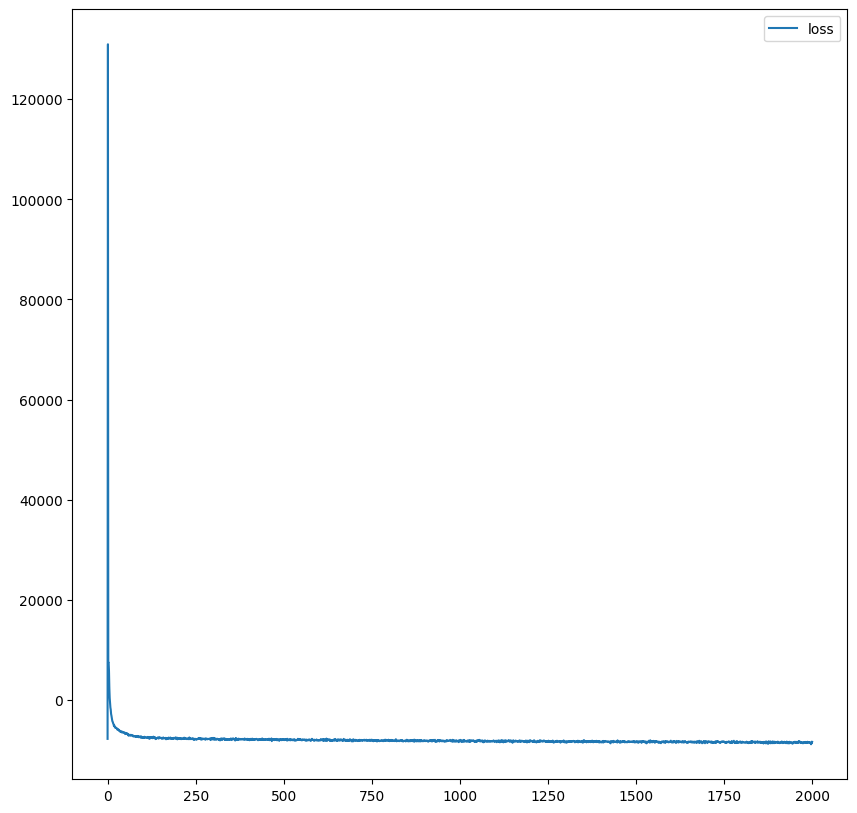

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

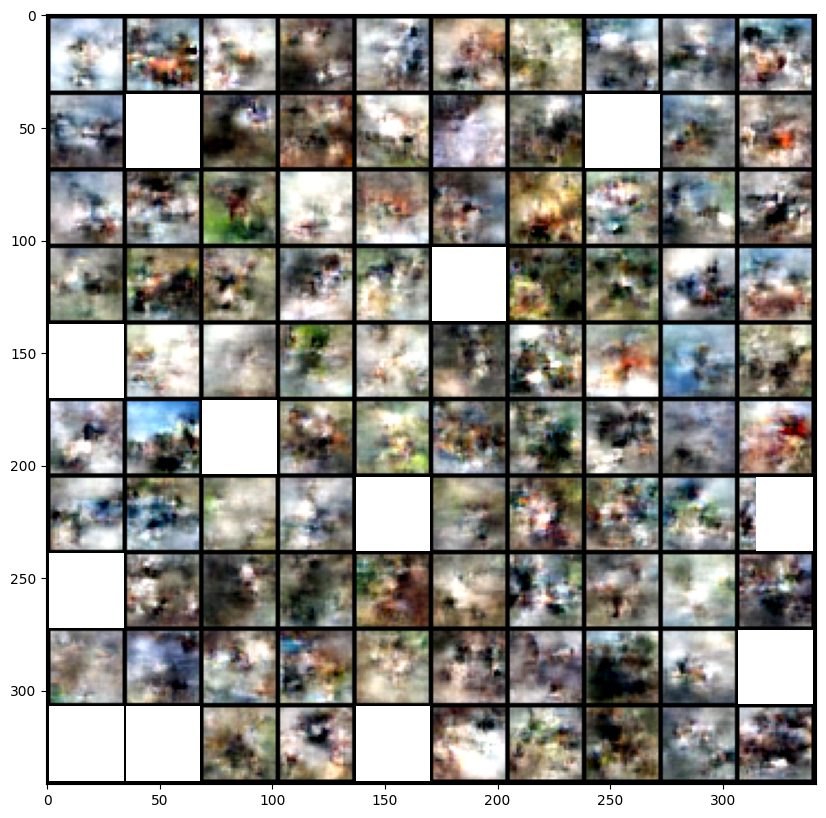

In [ ]:
#evaluation

# Model samples
num_sample = 10

with torch.no_grad():
    y = torch.arange(num_classes).repeat(num_sample).to(device)
    x, _ = model.sample(y=y)
    x_ = torch.clamp(x, 0, 1)
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(tv.utils.make_grid(x_, nrow=num_classes).cpu().numpy(), (1, 2, 0)))
    plt.show()

In [ ]:
# Get bits per dim
n = 0
bpd_cum = 0
with torch.no_grad():
    for x, y in iter(test_loader):
        nll = model(x.to(device), y.to(device))
        nll_np = nll.cpu().numpy()
        bpd_cum += np.nansum(nll_np / np.log(2) / n_dims + 8)
        n += len(x) - np.sum(np.isnan(nll_np))

    print('Bits per dim: ', bpd_cum / n)

Bits per dim:  4.388568736534971


#MAF (Masked Autoregressive Flow)
Modela transformaciones autoregresivas enmascaradas para construir flujos normalizadores invertibles., Su bijector implementa un modelo autorregresivo gaussiano condicional. A continuación, sus componentes clave:

1. Transformación Autoregresiva Enmascarada:
  Para un vector de entrada $x=[x_1,x_2,…,x_D]$, cada componente $y_i$​ se calcula de manera dependiente y secuencial:
  \begin{equation}
  y_i = x_i \odot \exp\big(s_i(x_{1:i-1})\big) + t_i(x_{1:i-1}),
  \end{equation}
  donde:
  * $s_i(⋅)$ y $t_i(⋅)$: Redes neuronales enmascaradas que garantizan que $y_i$ y dependa solo de $x_{1:i−1}$

  * ⊙: Producto elemento a elemento (Hadamard).

2. Enmascaramiento Autoregresivo (MADE)
  Las redes $s$ y $t$ se implementan con MADE (Masked Autoencoder for Distribution Estimation):
  \begin{equation}
  [s(\mathbf{x}), t(\mathbf{x})] = \text{MADE}(\mathbf{x}),
  \end{equation}
  con máscaras binarias que imponen:
  \begin{equation}
  \frac{\partial s_i}{\partial x_j} = 0 \quad \text{y} \quad \frac{\partial t_i}{\partial x_j} = 0 \quad \forall j \geq i.
  \end{equation}

3. Inversa de la Transformación
La operación inversa es secuencial y computacionalmente costosa:
  \begin{equation}
  x_i = \big(y_i - t_i(x_{1:i-1})\big) \odot \exp\big(-s_i(x_{1:i-1})\big).
  \end{equation}

4. Log-Determinante del Jacobiano
El Jacobiano es triangular inferior, lo que permite calcular el determinante eficientemente:
  \begin{equation}
  \log \left| \det \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \right| = \sum_{i=1}^D s_i(x_{1:i-1}).
  \end{equation}

5. Muestreo de Datos
Generar muestras requiere un proceso secuencial (lento en alta dimensión):
\begin{equation}
x_i \sim p(x_i | x_{1:i-1}) = \mathcal{N}\big(t_i(x_{1:i-1}), \exp(s_i(x_{1:i-1}))\big).
\end{equation}

In [1]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 894.9 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 36.2 MB/s eta 0:00:00
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size

<ipython-input-53-03b2b6623b4f>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.6, cmap='cool')


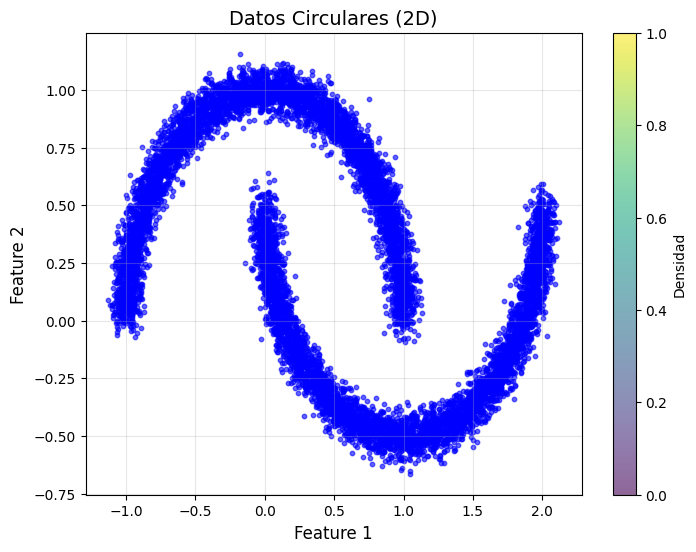

In [53]:
from sklearn.datasets import make_moons, make_circles
# moons
data = make_moons(n_samples=10000, noise=0.05)[0].astype(np.float32)
# Circles
# data = make_circles(n_samples=1000, noise=0.05, factor=0.5)[0].astype(np.float32)
data = data.astype(np.float32)
input_dim = data.shape[1]

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.6, cmap='cool')
plt.title("Datos Circulares (2D)", fontsize=14)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Densidad')
plt.show()



In [88]:
# 2. Definir modelo MAF
input_dim = data.shape[1]
# input_dim = 784
num_flows = 6 #capas
hidden_units = 128
num_blocks = 3 if input_dim > 1000 else 2 #menos bloques, mas rapido

scaler = torch.cuda.amp.GradScaler()#precisión mixta (FP16)
torch.cuda.empty_cache() #Limpiar memoria

# Crear flujo MAF (bijectors)
flows = []
for _ in range(num_flows):
    # Capa MAF con red neuronal profunda
    flows += [nf.flows.MaskedAffineAutoregressive(
        features=input_dim,
        hidden_features=hidden_units,
        num_blocks=num_blocks,
        activation=torch.nn.ReLU(),
        use_batch_norm=False
    ),nf.flows.Permute(input_dim, mode='swap')] #puede ir sin capa permute


# Distribución base (Gaussiana) q0 z
base = nf.distributions.base.DiagGaussian(input_dim)

# Modelo completo
model = nf.NormalizingFlow(base, flows)

<ipython-input-88-e1622a75552d>:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()#precisión mixta (FP16)


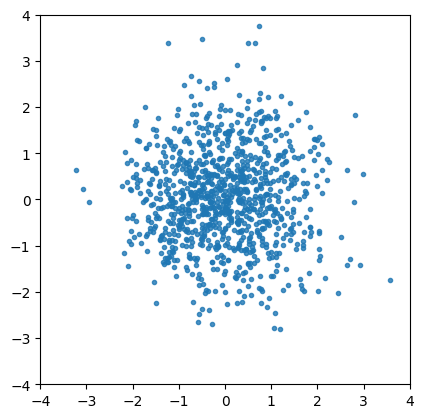

In [89]:
zsamples = base.sample(1000) #q0 base z
plt.plot(zsamples[:, 0].detach().numpy(), zsamples[:, 1].detach().numpy(), ".", alpha=0.8)
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect("equal")

  0%|          | 0/1000 [00:00<?, ?it/s]<ipython-input-90-1693fd799e5b>:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 1000/1000 [01:12<00:00, 13.87it/s]


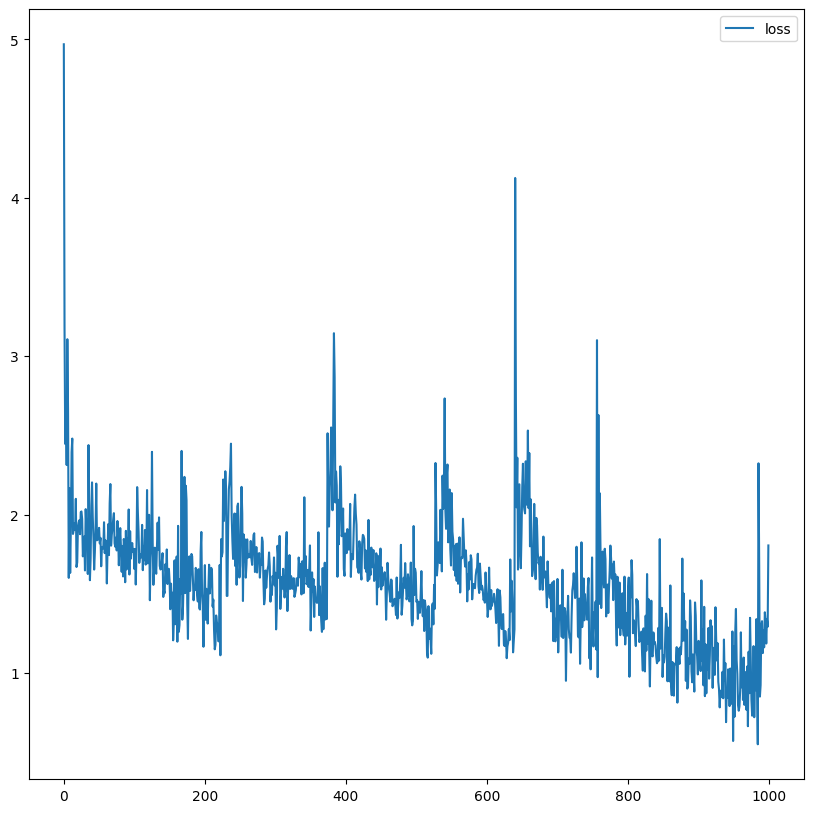

In [90]:
import torch
# 3. Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
train_loader = torch.utils.data.DataLoader(torch.tensor(data),
                                         batch_size=256,
                                         shuffle=True)


# Train model
max_iter = 1000 #20000
loss_hist = np.array([])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #adamw

for i in tqdm(range(max_iter)):
    for batch in train_loader:
        batch = batch.to(device)

    optimizer.zero_grad()

      # Activar modo de precisión mixta
    with torch.cuda.amp.autocast():
        loss = model.forward_kld(batch)

    loss.backward()
    optimizer.step()
    loss_hist = np.append(loss_hist, loss.detach().to('cpu').numpy())


plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

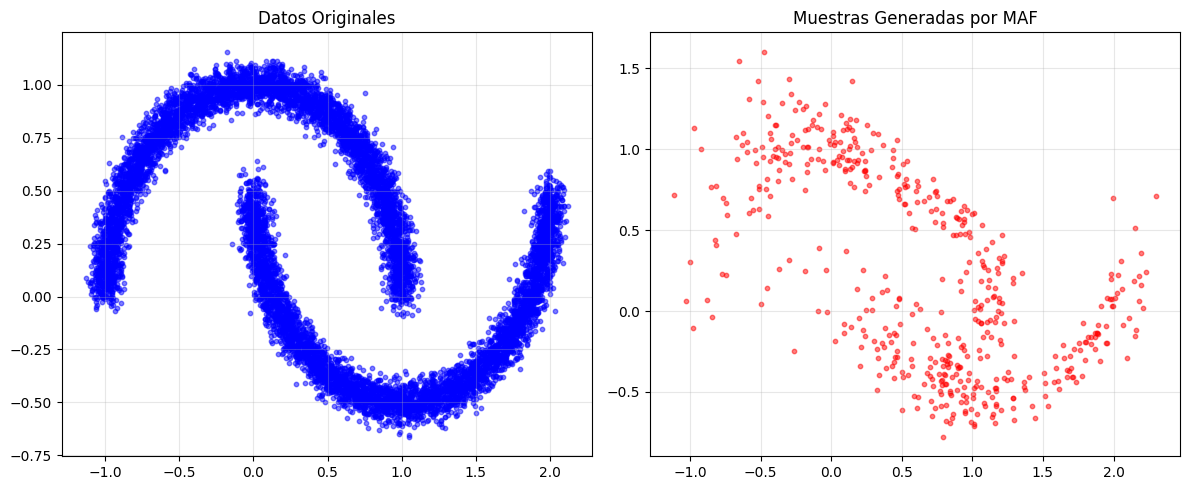

In [91]:
# 4. Generar muestras
model.eval()
with torch.no_grad():
    samples, _ = model.sample(500)
    samples = samples.cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.5)
plt.title("Datos Originales")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], c='red', s=10, alpha=0.5)
plt.title("Muestras Generadas por MAF")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/09-normalizing-flows.html

# Neural Spline Flow
Un NSF modela transformaciones mediante splines cúbicos parametrizados por redes neuronales. Para un vector de entrada $x∈R^D$:
\begin{equation}
\mathbf{y}_{1:d} = \mathbf{x}_{1:d}, \quad \mathbf{y}_{d+1:D} = \tau(\mathbf{x}_{d+1:D}; {\theta}(\mathbf{x}_{1:d}))
\end{equation}

* $τ$: Spline cúbico parametrizado.

* $θ$: Parámetros del spline (nodos, derivadas) generados por una red neuronal.


1. Definición del Spline Cúbico

Para cada dimensión transformada $y_i \in[a, b]$ (intervalo acotado):
Nodos y Valores

$$
\left\{\left(x^{(k)}, y^{(k)}\right)\right\}_{k=0}^K \operatorname{con} a=x^{(0)}<x^{(1)}<\cdots<x^{(K)}=b .
$$


Spline Cúbico (Por Partes)
En cada intervalo $\left[x^{(k)}, x^{(k+1)}\right]$ :
\begin{equation}
\tau(x) = \alpha^{(k)} + \beta^{(k)}(x - x^{(k)}) + \gamma^{(k)}(x - x^{(k)})^2 + \delta^{(k)}(x - x^{(k)})^3
\end{equation}

2. Transformación y Derivada
La transformación es monótona y diferenciable, con derivada:
\begin{equation}
\tau'(x) = \beta^{(k)} + 2\gamma^{(k)}(x - x^{(k)}) + 3\delta^{(k)}(x - x^{(k)})^2 > 0
\end{equation}

3. Parámetros del Spline (Generados por Red Neuronal)
La red neuronal$θ(x_{1:d})$ predice:
\begin{equation}
{\theta} = \left[\{\Delta x^{(k)}, \Delta y^{(k)}, \beta^{(k)}, \gamma^{(k)}, \delta^{(k)}\}_{k=1}^K\right]
\end{equation}
* $\Delta x^{(k)}=x^{(k)}-x^{(k-1)}$ (espaciado entre nodos).
* $\Delta y^{(k)}=y^{(k)}-y^{(k-1)}$ (incrementos en el rango).

4. Log-Determinante del Jacobiano
Para las dimensiones transformadas $(d+1:D)$:
\begin{equation}
\log \left| \det \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \right| = \sum_{i=d+1}^D \log \tau'(x_i)
\end{equation}

5. Entrenamiento por Máxima Verosimilitud
Función de pérdida (Negative Log-Likelihood):

\begin{equation}
\mathcal{L} = -\mathbb{E}_{\mathbf{x} \sim p_{\text{data}}} \left[ \log p_{\text{base}}(\tau^{-1}(\mathbf{y})) + \sum_{i=d+1}^D \log \tau'(x_i) \right]
\end{equation}

In [92]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

In [93]:
# Set up model

# Define flows
K = 16
torch.manual_seed(0)

latent_size = 2
hidden_units = 128
hidden_layers = 2

flows = []
for i in range(K):
    flows += [nf.flows.AutoregressiveRationalQuadraticSpline(latent_size, hidden_layers, hidden_units)]
    flows += [nf.flows.LULinearPermute(latent_size)]

# Set base distribuiton
q0 = nf.distributions.DiagGaussian(2, trainable=False)

# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows)

# Move model on GPU if available
enable_cuda = True
device = torch.device('cuda' if torch.cuda.is_available() and enable_cuda else 'cpu')
nfm = nfm.to(device)

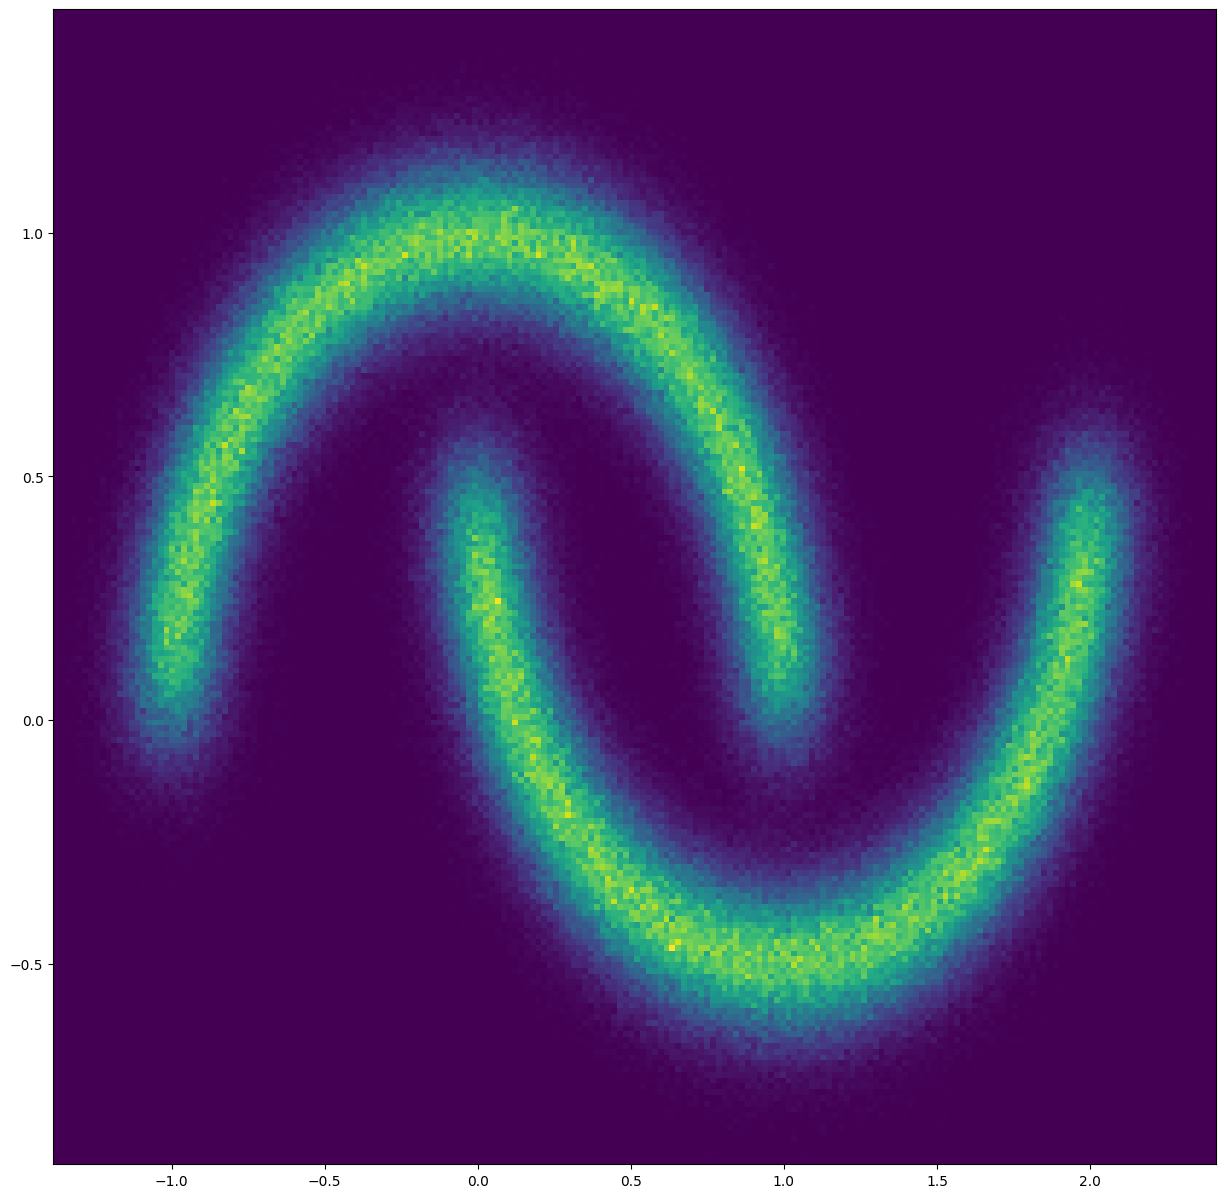

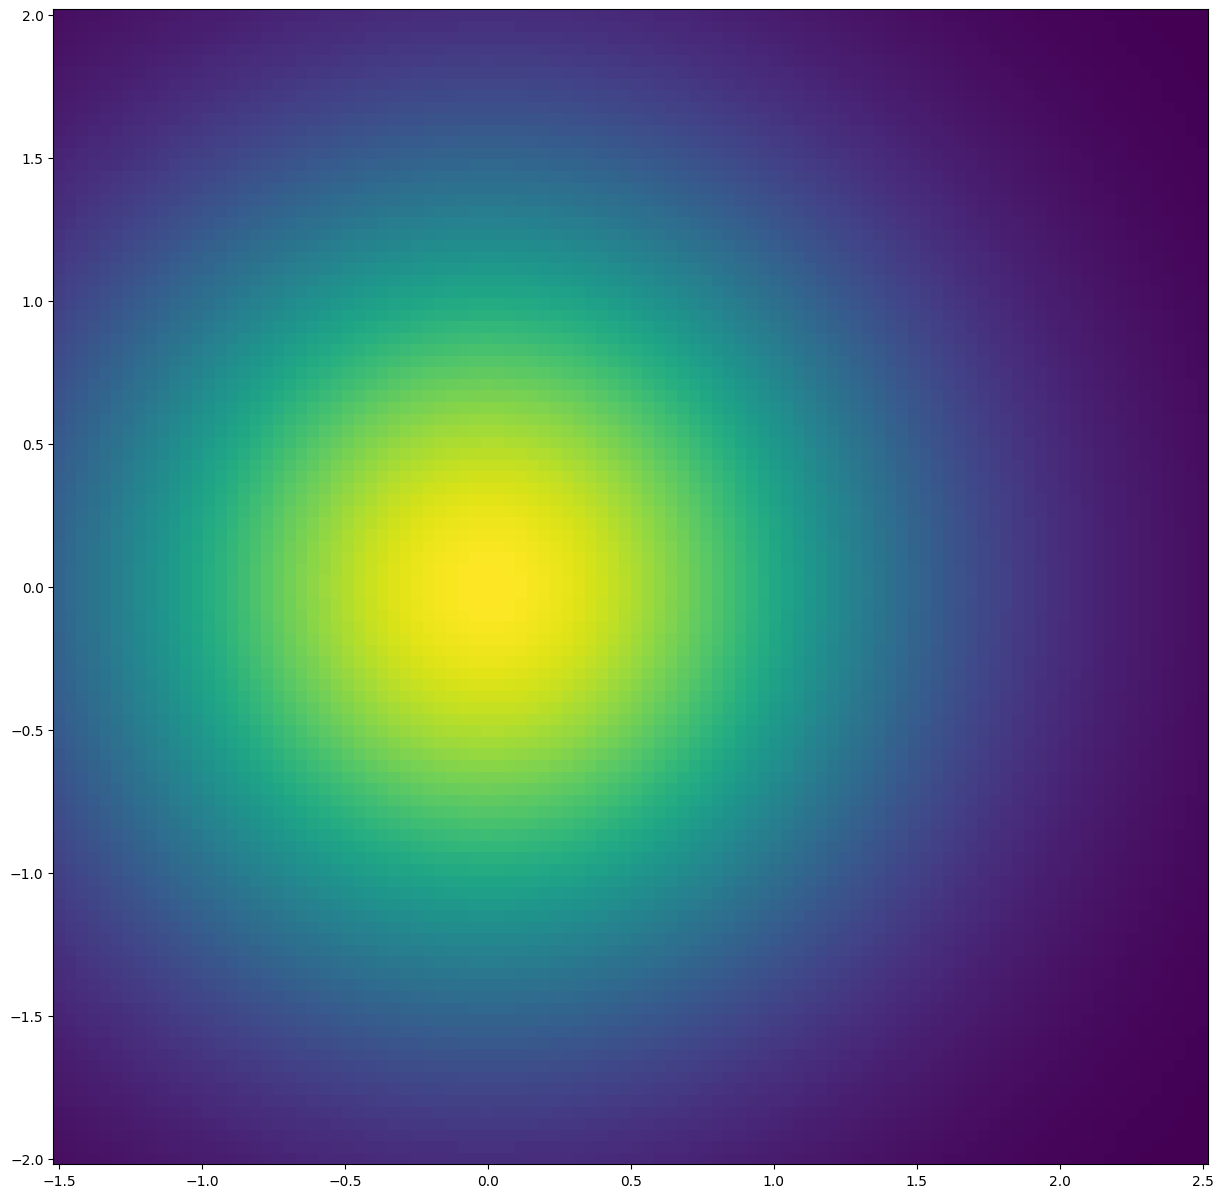

In [94]:
# Plot target distribution
x_np, _ = make_moons(2 ** 20, noise=0.1)
plt.figure(figsize=(15, 15))
plt.hist2d(x_np[:, 0], x_np[:, 1], bins=200)
plt.show()

# Plot initial flow distribution
grid_size = 100
xx, yy = torch.meshgrid(torch.linspace(-1.5, 2.5, grid_size), torch.linspace(-2, 2, grid_size))
zz = torch.cat([xx.unsqueeze(2), yy.unsqueeze(2)], 2).view(-1, 2)
zz = zz.to(device)

nfm.eval()
log_prob = nfm.log_prob(zz).to('cpu').view(*xx.shape)
nfm.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy())
plt.gca().set_aspect('equal', 'box')
plt.show()

100%|██████████| 100/100 [00:19<00:00,  5.12it/s]


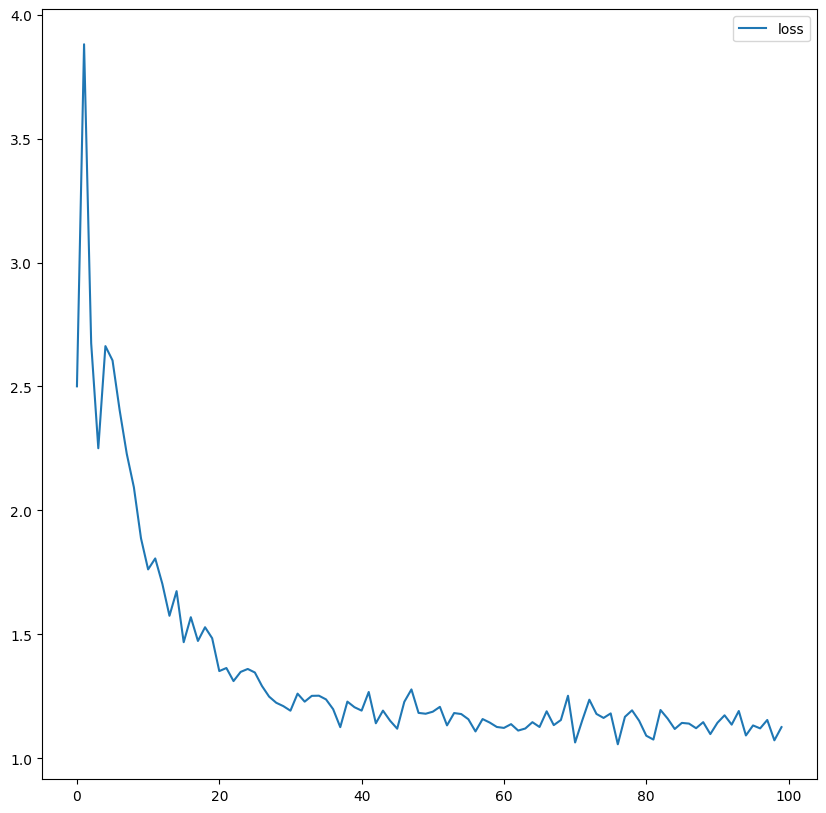

In [95]:
# Train model
max_iter = 100
num_samples = 2 ** 9
show_iter = 500


loss_hist = np.array([])

optimizer = torch.optim.Adam(nfm.parameters(), lr=1e-3, weight_decay=1e-5)
for it in tqdm(range(max_iter)):
    optimizer.zero_grad()

    # Get training samples
    x_np, _ = make_moons(num_samples, noise=0.1)
    x = torch.tensor(x_np).float().to(device)

    # Compute loss
    loss = nfm.forward_kld(x)

    # Do backprop and optimizer step
    if ~(torch.isnan(loss) | torch.isinf(loss)):
        loss.backward()
        optimizer.step()

    # Log loss
    loss_hist = np.append(loss_hist, loss.to('cpu').data.numpy())

    # Plot learned distribution
    if (it + 1) % show_iter == 0:
        nfm.eval()
        log_prob = nfm.log_prob(zz)
        nfm.train()
        prob = torch.exp(log_prob.to('cpu').view(*xx.shape))
        prob[torch.isnan(prob)] = 0

        plt.figure(figsize=(15, 15))
        plt.pcolormesh(xx, yy, prob.data.numpy())
        plt.gca().set_aspect('equal', 'box')
        plt.show()

# Plot loss
plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

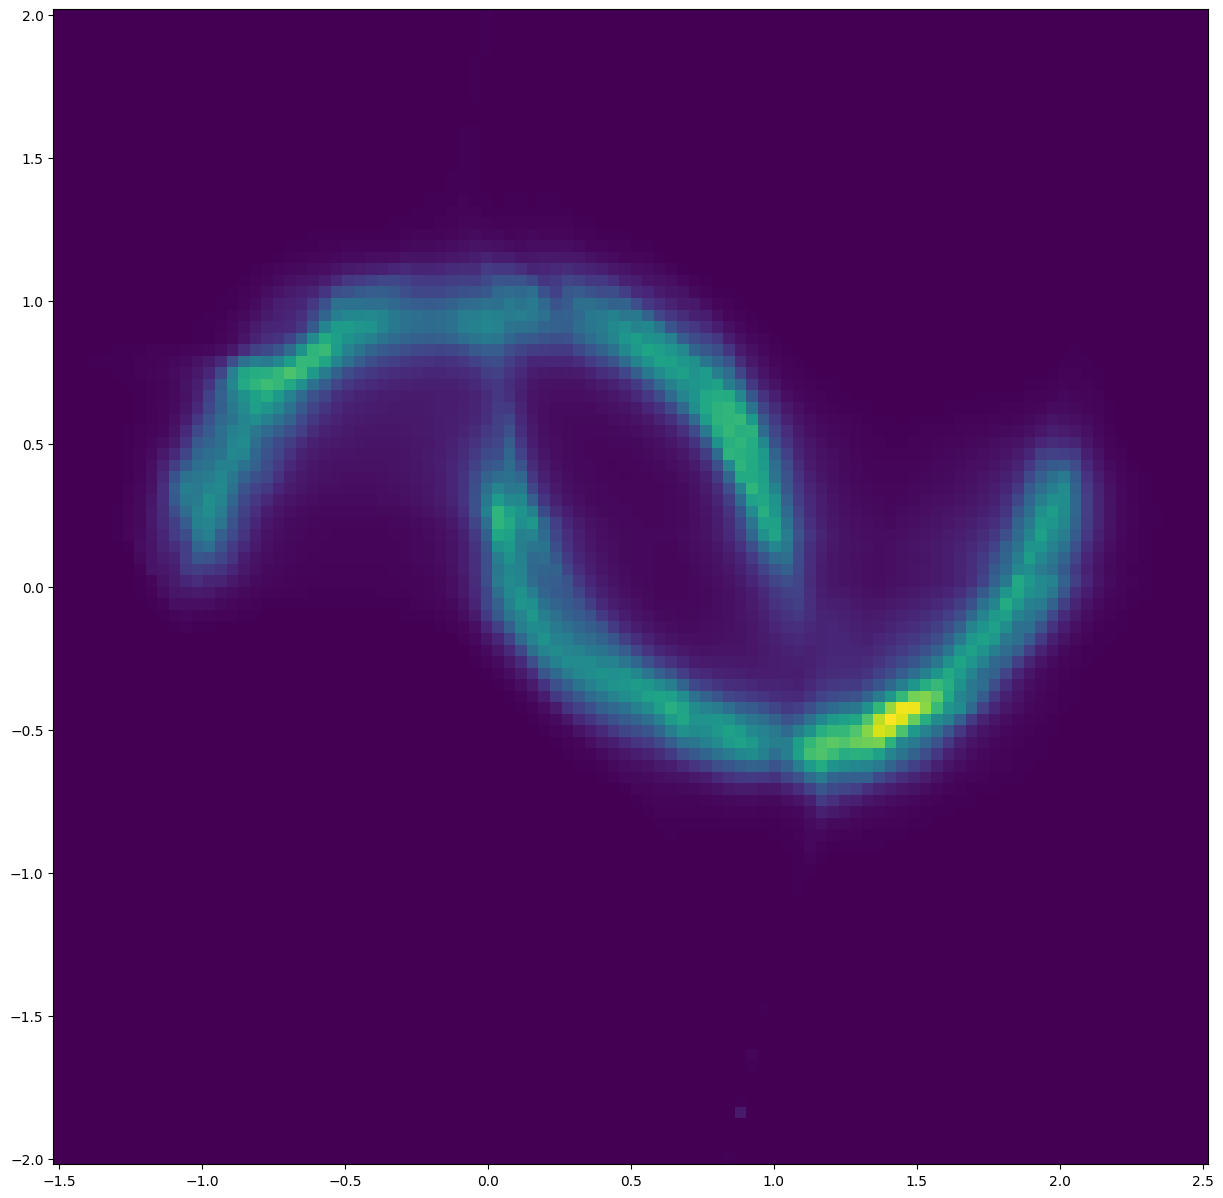

In [96]:
# Plot learned distribution
nfm.eval()
log_prob = nfm.log_prob(zz).to('cpu').view(*xx.shape)
nfm.train()
prob = torch.exp(log_prob)
prob[torch.isnan(prob)] = 0

plt.figure(figsize=(15, 15))
plt.pcolormesh(xx, yy, prob.data.numpy())
plt.gca().set_aspect('equal', 'box')
plt.show()

# Stochastic Normalizing Flow	 (SNF)

Combina transformaciones deterministas (flujos invertibles) con pasos estocásticos (MCMC) para modelar distribuciones complejas. Su estructura general se basa en la Alternancia entre capas deterministas y estocásticas

\begin{equation}
\mathbf{z}_0 \sim p_{\text{base}}(\mathbf{z}_0), \quad  
\mathbf{z}_\ell = f_\ell(\mathbf{z}_{\ell-1}), \quad  
\mathbf{z}_{\ell+1} \sim \mathcal{T}(\mathbf{z}_{\ell+1} | \mathbf{z}_\ell).
\end{equation}

1. Capa Determinista (MAF)
\begin{equation}
y_i = x_i \odot \exp\left(s_i(x_{1:i-1})\right) + t_i(x_{1:i-1}),
\end{equation}
2. Log-determinante del Jacobiano:
\begin{equation}
\log \left| \det \frac{\partial \mathbf{y}}{\partial \mathbf{x}} \right| = \sum_{i=1}^D s_i(x_{1:i-1}).
\end{equation}
3. Capa Estocástica (Metropolis-Hastings)
Distribución propuesta:
\begin{equation}
q(\mathbf{z}' | \mathbf{z}) = \mathcal{N}(\mathbf{z}' | \mathbf{z}, \sigma^2 \mathbf{I}),
\end{equation}
Probabilidad de aceptación:
\begin{equation}
\alpha = \min (1, \frac{p(\mathbf{z}')}{p(\mathbf{z})} \cdot \frac{q(\mathbf{z} | \mathbf{z}')}{q(\mathbf{z}' | \mathbf{z})}).
\end{equation}
Energía de la distribución base:
\begin{equation}
U(\mathbf{z}) = -\log p_{\text{base}}(\mathbf{z}) = \frac{1}{2} \|\mathbf{z}\|^2 \quad \text{(si } p_{\text{base}} = \mathcal{N}(0, \mathbf{I})).
\end{equation}
4. Densidad del Modelo
\begin{equation}
\log p(\mathbf{x}) = \log p_{\text{base}}(\mathbf{z}_L) + \sum_{\ell} \log | \det \frac{\partial f_\ell}{\partial \mathbf{z}_{\ell-1}| - \sum_{k} \log \mathcal{T}(\mathbf{z}_k | \mathbf{z}_{k-1}}).
\end{equation}

5. Función de Pérdida (Forward KL)
\begin{equation}
\mathcal{L} = \mathbb{E}_{\mathbf{x} \sim p_{\text{data}}} \left[ -\log p(\mathbf{x}) \right].
\end{equation}

In [ ]:
!pip install normflows
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
import numpy as np

import torch
import normflows as nf
from tqdm import tqdm

<ipython-input-101-03b2b6623b4f>:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.6, cmap='cool')


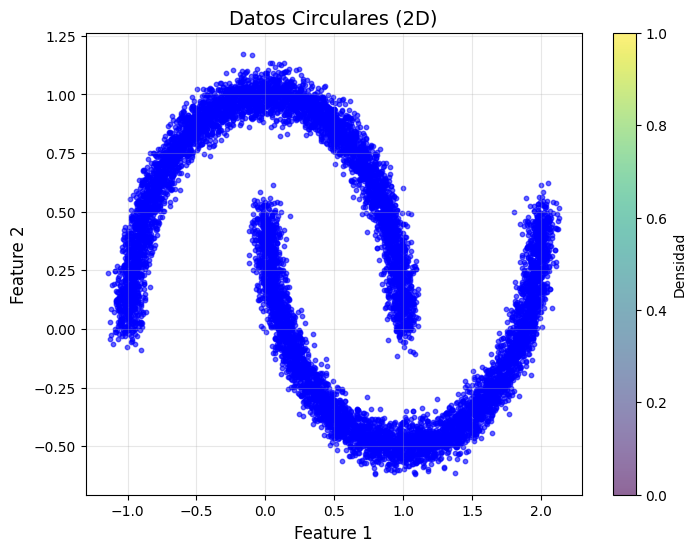

In [101]:
from sklearn.datasets import make_moons, make_circles
# moons
data = make_moons(n_samples=10000, noise=0.05)[0].astype(np.float32)
# Circles
# data = make_circles(n_samples=1000, noise=0.05, factor=0.5)[0].astype(np.float32)
data = data.astype(np.float32)
input_dim = data.shape[1]

plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.6, cmap='cool')
plt.title("Datos Circulares (2D)", fontsize=14)
plt.xlabel("Feature 1", fontsize=12)
plt.ylabel("Feature 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.colorbar(label='Densidad')
plt.show()



In [105]:
from normflows.flows import Flow

class MetropolisAdjustedLayer(Flow):
    def __init__(self, target_energy, step_size=0.1):
        super().__init__()
        self.target_energy = target_energy
        self.step_size = step_size

    def forward(self, z):
        # Paso de Metropolis-Hastings
        z_new = z + self.step_size * torch.randn_like(z)
        log_ratio = -self.target_energy(z_new) + self.target_energy(z)
        accept = torch.rand(z.shape[0], device=z.device) < torch.exp(log_ratio)
        z_out = torch.where(accept.unsqueeze(-1), z_new, z)
        return z_out, torch.zeros(z.shape[0], device=z.device)  # log_prob = 0

    def inverse(self, z):
        # Inversa (no se usa en entrenamiento)
        return z, torch.zeros(z.shape[0], device=z.device)

# 2. Configurar modelo y entrenamiento
input_dim = 2
flows = [
    nf.flows.MaskedAffineAutoregressive(features=input_dim, hidden_features=64),
    MetropolisAdjustedLayer(target_energy=lambda z: 0.5 * torch.sum(z**2, dim=1))
]

base = nf.distributions.base.DiagGaussian(input_dim)
model = nf.NormalizingFlow(base, flows)


  0%|          | 0/1000 [00:00<?, ?it/s]<ipython-input-106-1693fd799e5b>:22: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 1000/1000 [00:45<00:00, 21.77it/s]


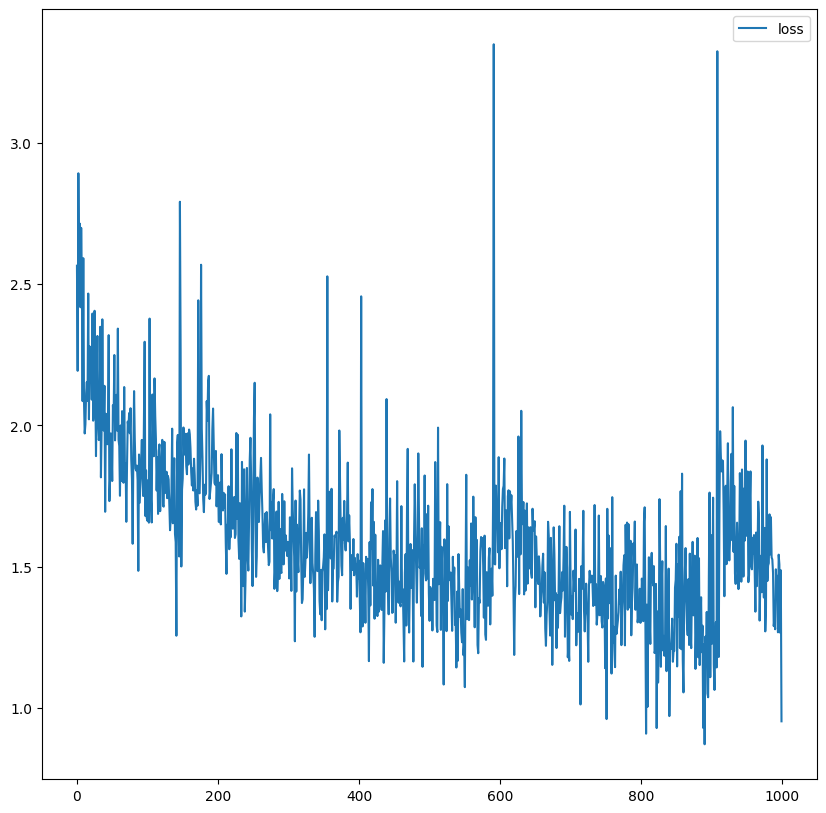

In [106]:
import torch
# 3. Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
train_loader = torch.utils.data.DataLoader(torch.tensor(data),
                                         batch_size=256,
                                         shuffle=True)


# Train model
max_iter = 1000 #20000
loss_hist = np.array([])
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #adamw

for i in tqdm(range(max_iter)):
    for batch in train_loader:
        batch = batch.to(device)

    optimizer.zero_grad()

      # Activar modo de precisión mixta
    with torch.cuda.amp.autocast():
        loss = model.forward_kld(batch)

    loss.backward()
    optimizer.step()
    loss_hist = np.append(loss_hist, loss.detach().to('cpu').numpy())


plt.figure(figsize=(10, 10))
plt.plot(loss_hist, label='loss')
plt.legend()
plt.show()

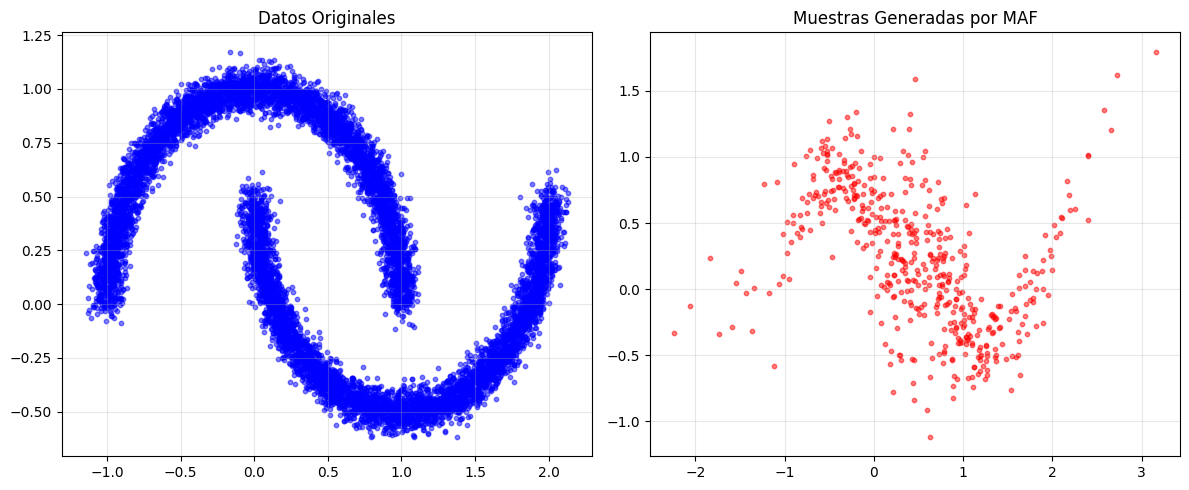

In [107]:
# 4. Generar muestras
model.eval()
with torch.no_grad():
    samples, _ = model.sample(500)
    samples = samples.cpu().numpy()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], c='blue', s=10, alpha=0.5)
plt.title("Datos Originales")
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0], samples[:, 1], c='red', s=10, alpha=0.5)
plt.title("Muestras Generadas por MAF")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()